# Main

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
# df_time = pd.read_csv('/content/BTP_FinalData - Sheet1.csv')
df_time = pd.read_csv('/content/drive/MyDrive/BTP_Sensor 2024/OneDrive_1_9-5-2024/BTP_Time_data.csv')
# print(df_time.head())
df_time

,Repeat,Point,Gate Voltage,Gate Current,Gate Time,Drain Voltage,Drain Current,Drain Time,Concentration (mM)
0,1,1,-0.4,-1.900000e-06,0.0,-0.5,-0.000679,0.0,20.0
1,1,2,-0.4,-1.900000e-06,0.5,-0.5,-0.000679,0.5,20.0
2,1,3,-0.4,-1.600000e-06,1.0,-0.5,-0.000679,1.0,20.0
3,1,4,-0.4,-1.400000e-06,1.5,-0.5,-0.000680,1.5,20.0
4,1,5,-0.4,-1.600000e-06,2.0,-0.5,-0.000680,2.0,20.0
...,...,...,...,...,...,...,...,...,...
796,1,801,-0.4,-1.800000e-06,89.0,-0.5,-0.000362,89.0,150.0
797,1,802,-0.4,-9.000000e-07,89.5,-0.5,-0.000362,89.5,150.0
798,1,803,-0.4,-1.600000e-06,90.0,-0.5,-0.000362,90.0,150.0
799,1,804,-0.4,-2.200000e-06,90.5,-0.5,-0.000361,90.5,150.0


In [ ]:
# import pandas as pd
# df_single = pd.read_csv('/content/drive/MyDrive/BTP_Sensor 2024/BTP_Na+.csv')
# # print(df_single.head())
# df_single

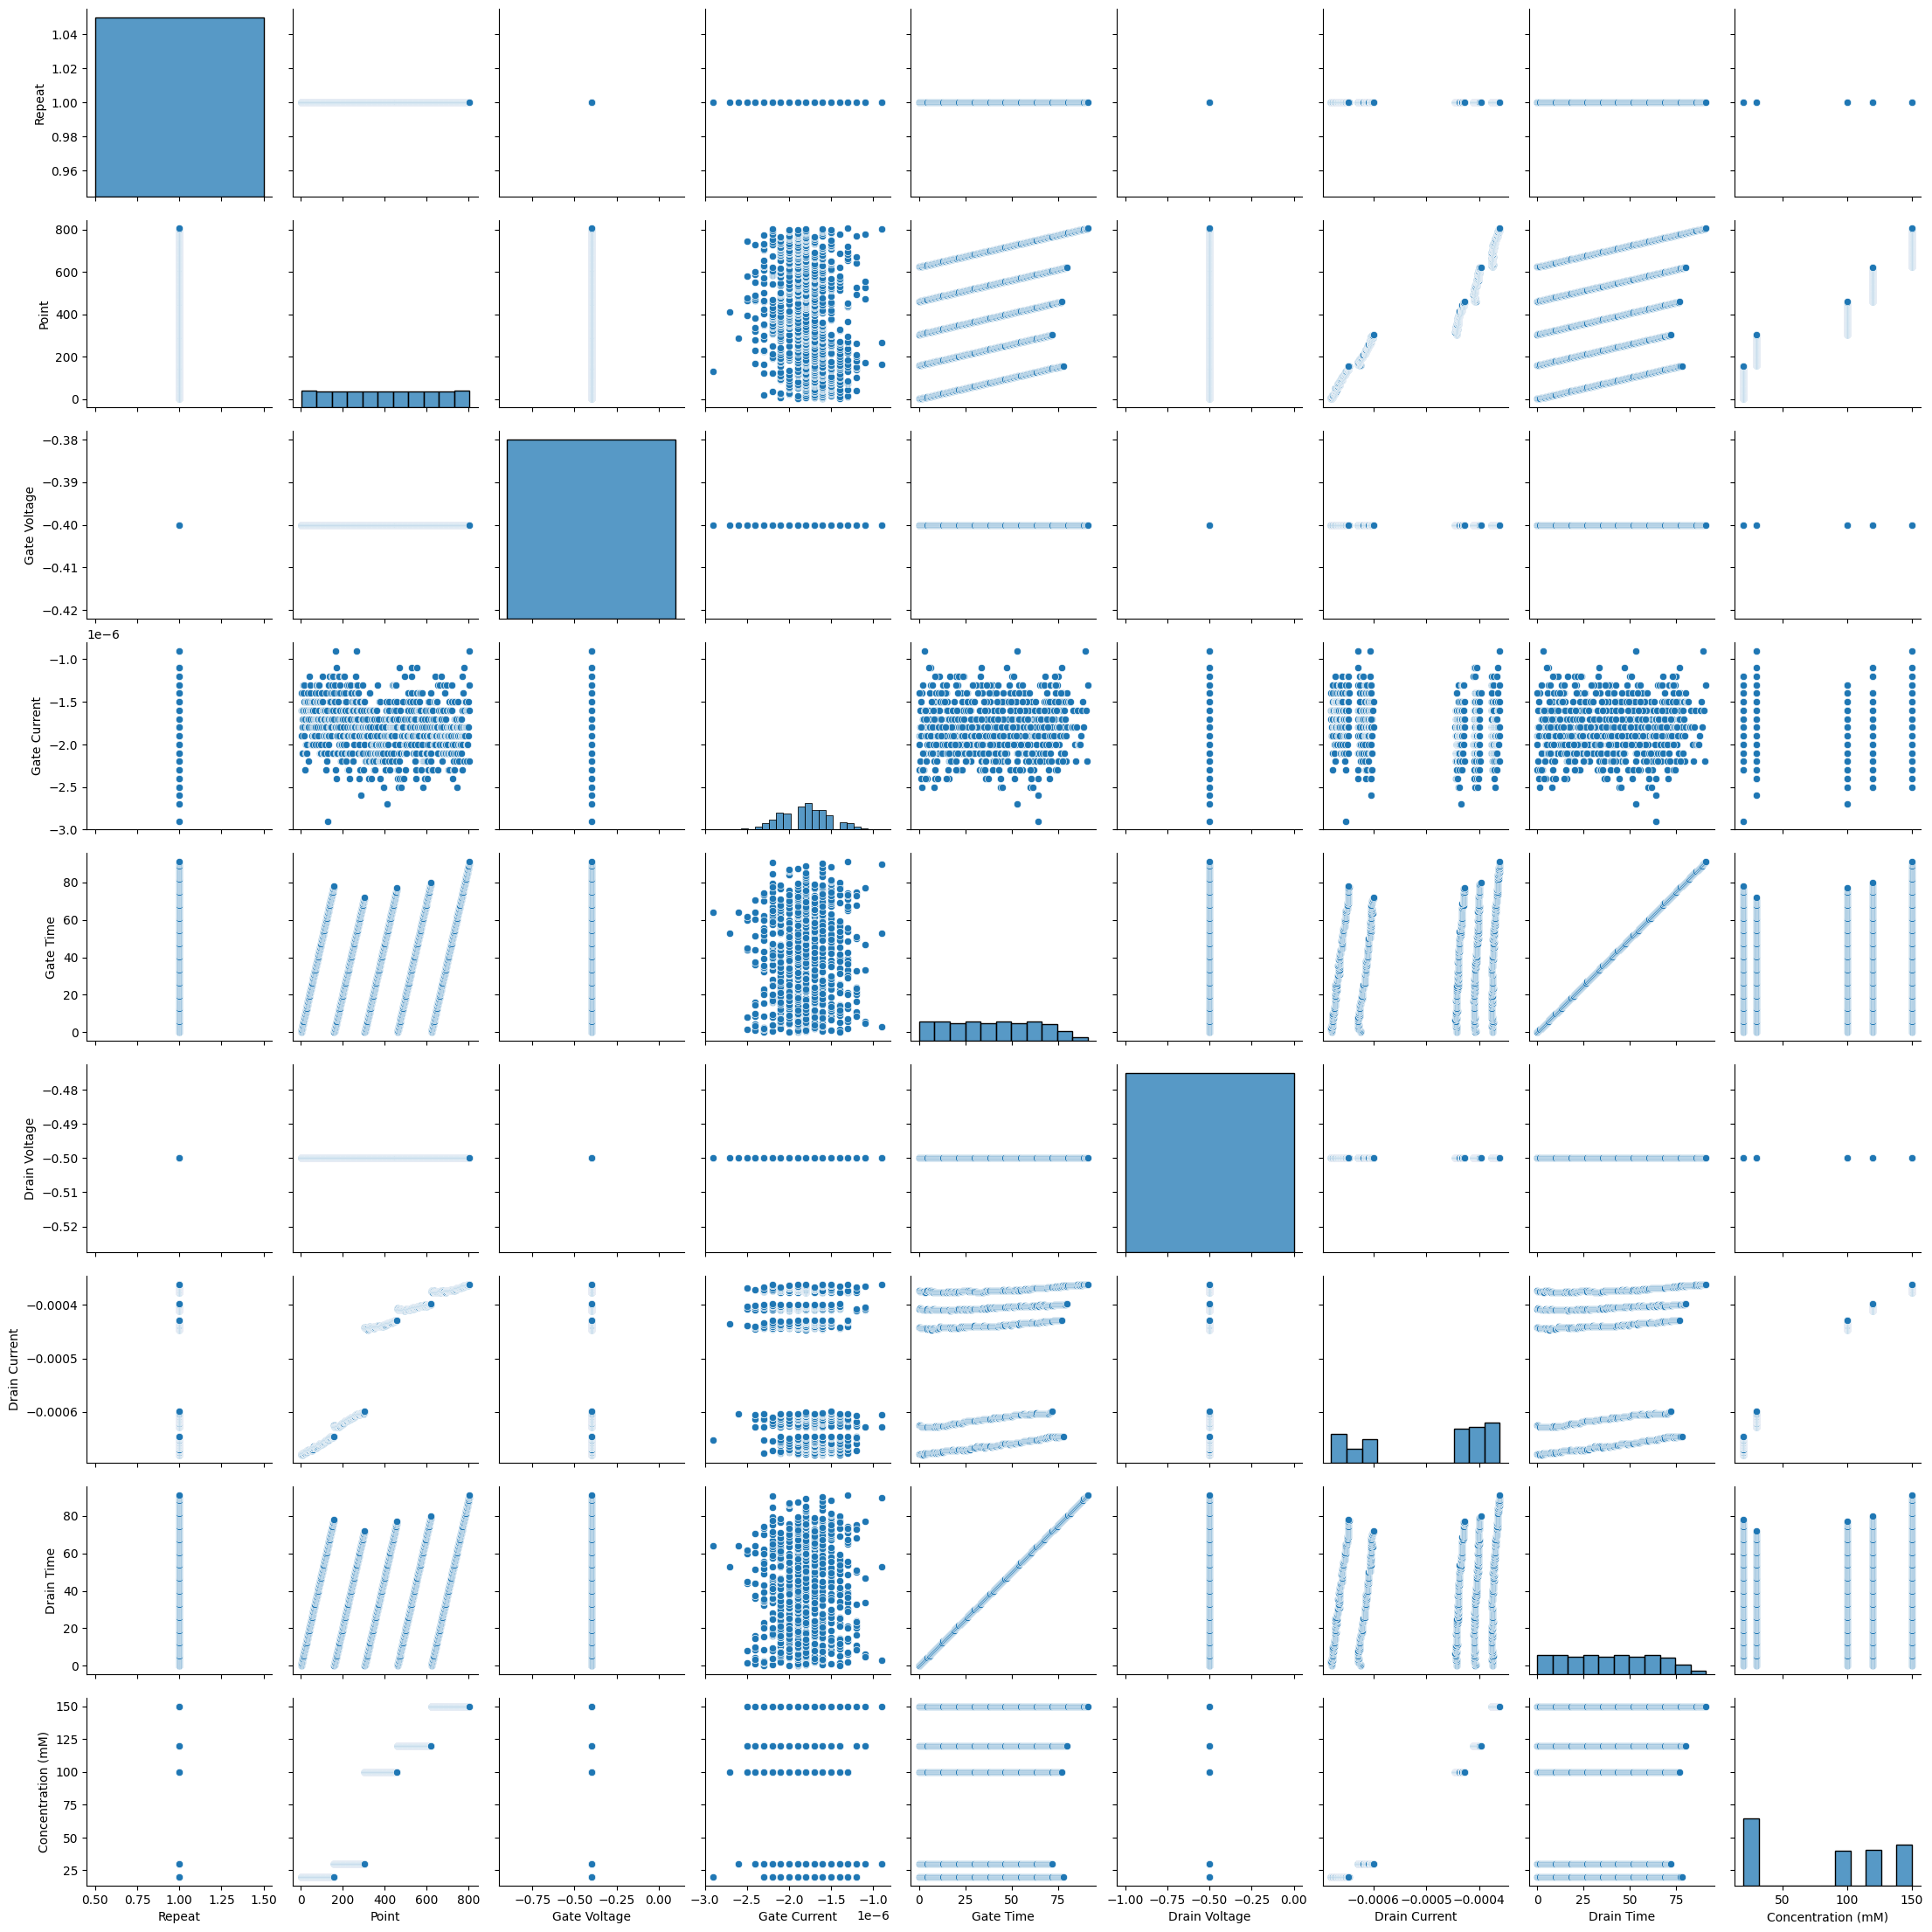

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df_time)
plt.show()

In [ ]:
data = df_time
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Repeat              801 non-null    int64  
 1   Point               801 non-null    int64  
 2   Gate Voltage        801 non-null    float64
 3   Gate Current        801 non-null    float64
 4   Gate Time           801 non-null    float64
 5   Drain Voltage       801 non-null    float64
 6   Drain Current       801 non-null    float64
 7   Drain Time          801 non-null    float64
 8   Concentration (mM)  801 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 56.4 KB


In [ ]:
data.describe()

,Repeat,Point,Gate Voltage,Gate Current,Gate Time,Drain Voltage,Drain Current,Drain Time,Concentration (mM)
count,801.0,801.000000,8.010000e+02,8.010000e+02,801.000000,801.0,801.000000,801.000000,801.000000
mean,1.0,403.084894,-4.000000e-01,-1.809114e-06,40.046192,-0.5,-0.000492,40.046192,87.091136
std,0.0,232.783613,1.388646e-15,2.934780e-07,23.576466,0.0,0.000118,23.576466,51.280142
min,1.0,1.000000,-4.000000e-01,-2.900000e-06,0.000000,-0.5,-0.000680,0.000000,20.000000
25%,1.0,202.000000,-4.000000e-01,-2.000000e-06,20.000000,-0.5,-0.000621,20.000000,30.000000
50%,1.0,403.000000,-4.000000e-01,-1.800000e-06,40.000000,-0.5,-0.000437,40.000000,100.000000
75%,1.0,604.000000,-4.000000e-01,-1.600000e-06,60.000000,-0.5,-0.000400,60.000000,120.000000
max,1.0,805.000000,-4.000000e-01,-9.000000e-07,91.000000,-0.5,-0.000361,91.000000,150.000000


In [ ]:
data.nunique()

,0
Repeat,1
Point,801
Gate Voltage,1
Gate Current,19
Gate Time,183
Drain Voltage,1
Drain Current,114
Drain Time,183
Concentration (mM),5


In [ ]:
data = data.drop(['Repeat', 'Drain Time','Gate Current','Drain Voltage','Point'], axis=1)
data

,Gate Voltage,Gate Time,Drain Current,Concentration (mM)
0,-0.4,0.0,-0.000679,20.0
1,-0.4,0.5,-0.000679,20.0
2,-0.4,1.0,-0.000679,20.0
3,-0.4,1.5,-0.000680,20.0
4,-0.4,2.0,-0.000680,20.0
...,...,...,...,...
796,-0.4,89.0,-0.000362,150.0
797,-0.4,89.5,-0.000362,150.0
798,-0.4,90.0,-0.000362,150.0
799,-0.4,90.5,-0.000361,150.0


In [ ]:
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


In [ ]:
data.isnull().sum()

,0
Gate Voltage,0
Gate Time,0
Drain Current,0
Concentration (mM),0


In [ ]:
# data = data.dropna()
# data.isnull().sum()

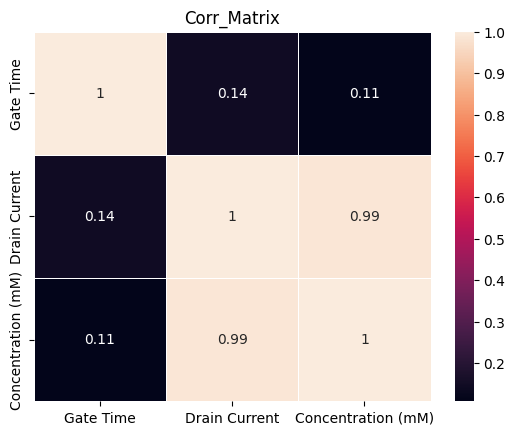

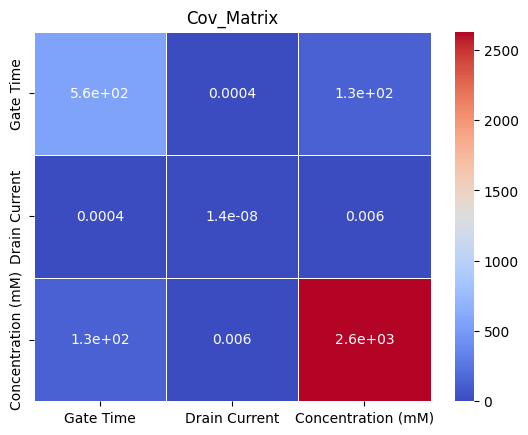

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_mat=data.iloc[:, 1:].corr()
sns.heatmap(corr_mat,annot=True,linewidth=.5)
plt.title('Corr_Matrix')
plt.show()
cov_mat=data.iloc[:, 1:].cov()
sns.heatmap(cov_mat,annot=True,linewidth=.5,cmap='coolwarm')
plt.title('Cov_Matrix')
plt.show()

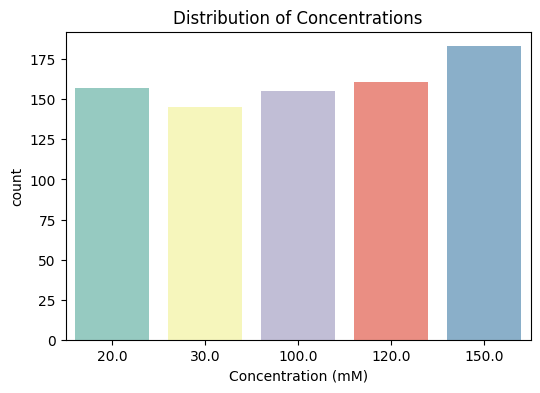

In [ ]:
# Visualize the distribution of the 'Conc' column
plt.figure(figsize=(6, 4))
sns.countplot(x='Concentration (mM)', data=data, palette='Set3')
plt.title('Distribution of Concentrations')
plt.show()

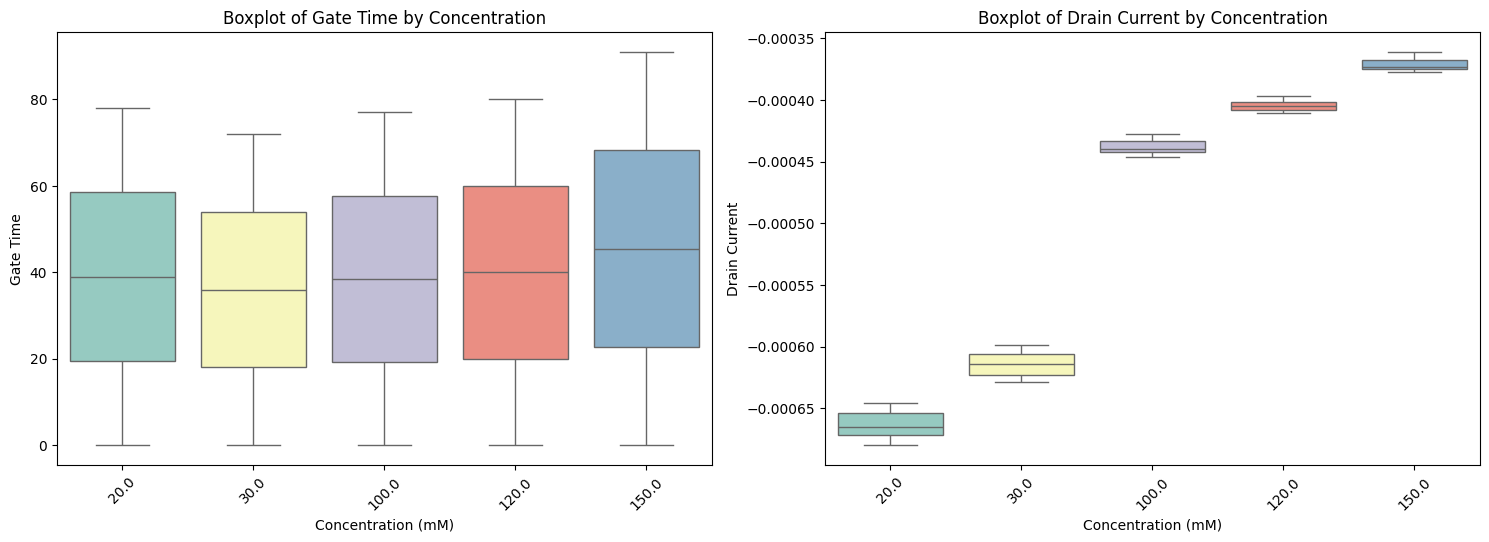

In [ ]:
plt.figure(figsize=(15, 10))  # Adjust figure size for multiple subplots

for i, col in enumerate(['Gate Time','Drain Current']):
    plt.subplot(2, 2, i + 1)  # Create subplots (adjust rows and columns as needed)
    sns.boxplot(x='Concentration (mM)', y=col, data=data, palette="Set3") # Use a color palette
    plt.title(f'Boxplot of {col} by Concentration')
    plt.xticks(rotation=45) # Rotate x-axis labels if needed
    plt.tight_layout() # Adjust layout to prevent overlapping

plt.show()

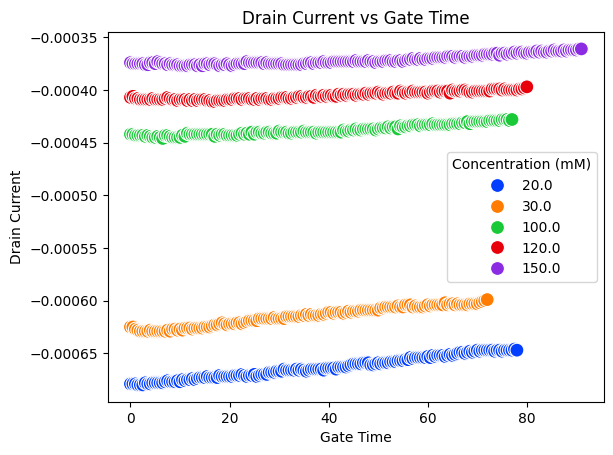

In [ ]:
sns.scatterplot(x='Gate Time', y='Drain Current', hue='Concentration (mM)', data=data, palette='bright', s=100)
plt.title('Drain Current vs Gate Time')
plt.figsize=(12,6)
plt.show()

#With Drain Current

In [ ]:
X = data[['Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
train_data = pd.DataFrame({'Drain Current': X_train['Drain Current'], 'Concentration (mM)': y_train})
test_data = pd.DataFrame({'Drain Current': X_test['Drain Current'], 'Concentration (mM)': y_test})

# Count entries for each concentration in the training set
train_counts = train_data['Concentration (mM)'].value_counts()
print("Training set concentration counts:")
display(train_counts)

# Count entries for each concentration in the testing set
test_counts = test_data['Concentration (mM)'].value_counts()
print("\nTesting set concentration counts:")
test_counts

Training set concentration counts:


,count
Concentration (mM),
150.0,143
120.0,129
20.0,125
100.0,124
30.0,119



Testing set concentration counts:


,count
Concentration (mM),
150.0,40
20.0,32
120.0,32
100.0,31
30.0,26


In [ ]:
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

train_data1 = pd.DataFrame({'Drain Current': X_train_resampled['Drain Current'], 'Concentration (mM)': y_train_resampled})
test_data1 = pd.DataFrame({'Drain Current': X_test['Drain Current'], 'Concentration (mM)': y_test})

# Count entries for each concentration in the training set
train_counts = train_data1['Concentration (mM)'].value_counts()
print("Training set concentration counts:")
display(train_counts)

# Count entries for each concentration in the testing set
test_counts = test_data1['Concentration (mM)'].value_counts()
print("\nTesting set concentration counts:")
test_counts

Training set concentration counts:


,count
Concentration (mM),
120.0,143
100.0,143
20.0,143
150.0,143
30.0,143



Testing set concentration counts:


,count
Concentration (mM),
150.0,40
20.0,32
120.0,32
100.0,31
30.0,26


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

Linear Regression:
Mean Squared Error: 76.49640904687372
Root Mean Squared Error: 8.746222558732068
Mean Absolute Error: 8.08862116245502
R-squared: 0.9711026150961124
---
Lasso Regression:
Mean Squared Error: 77.23972178338707
Root Mean Squared Error: 8.78861318885904
Mean Absolute Error: 8.057787778227055
R-squared: 0.9708218202912501
---
Gaussian Process:
Mean Squared Error: 27.187690059123767
Root Mean Squared Error: 5.214181628896693
Mean Absolute Error: 2.773738055495742
R-squared: 0.989729542156617
---
Support Vector Machine:
Mean Squared Error: 32.59222350234294
Root Mean Squared Error: 5.708959931751399
Mean Absolute Error: 4.515918304494626
R-squared: 0.9876879184375358
---
Gradient Boosting:
Mean Squared Error: 1.8724823737327243e-06
Root Mean Squared Error: 0.0013683867778273525
Mean Absolute Error: 0.0012579028949178447
R-squared: 0.9999999992926486
---
Decision Tree:
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0
R-squared: 1.0
---
Random Fo

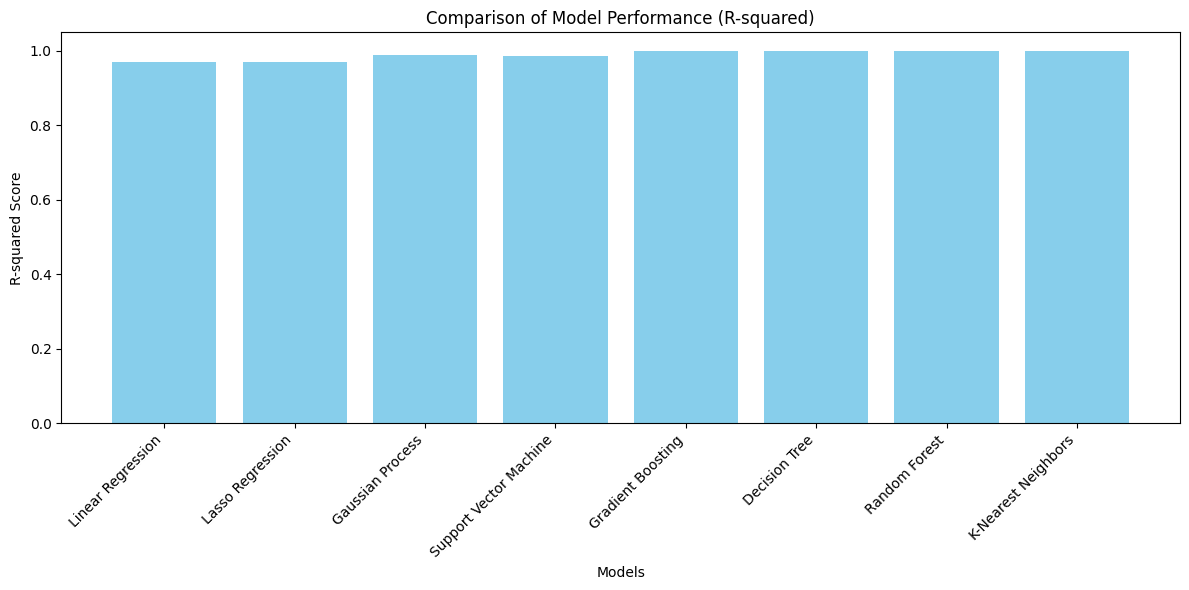

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from imblearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train different models
models = {
    'Linear Regression': LinearRegression(),
    # 'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names = []
r2_scores = []
predictions = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    model_names.append(name)
    predictions.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

###For SMOTE data

Linear Regression:
Mean Squared Error: 74.39194612452397
Root Mean Squared Error: 8.625076586588897
Mean Absolute Error: 7.724446943796296
R-squared: 0.9718975997998498
---
Lasso Regression:
Mean Squared Error: 76.26448826719789
Root Mean Squared Error: 8.732954154648809
Mean Absolute Error: 7.639282870878593
R-squared: 0.9711902257973337
---
Gaussian Process:
Mean Squared Error: 2.63055601780816
Root Mean Squared Error: 1.6218988925972422
Mean Absolute Error: 1.177459051890403
R-squared: 0.9990062776710047
---
Support Vector Machine:
Mean Squared Error: 33.52316457390825
Root Mean Squared Error: 5.789919219981247
Mean Absolute Error: 3.9774010990597652
R-squared: 0.9873362449040582
---
Gradient Boosting:
Mean Squared Error: 1.886624558469912e-06
Root Mean Squared Error: 0.001373544523657647
Mean Absolute Error: 0.001276926878201446
R-squared: 0.9999999992873062
---
Decision Tree:
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0
Mean Absolute Error: 0.0
R-squared: 1.0
---
Random Fo

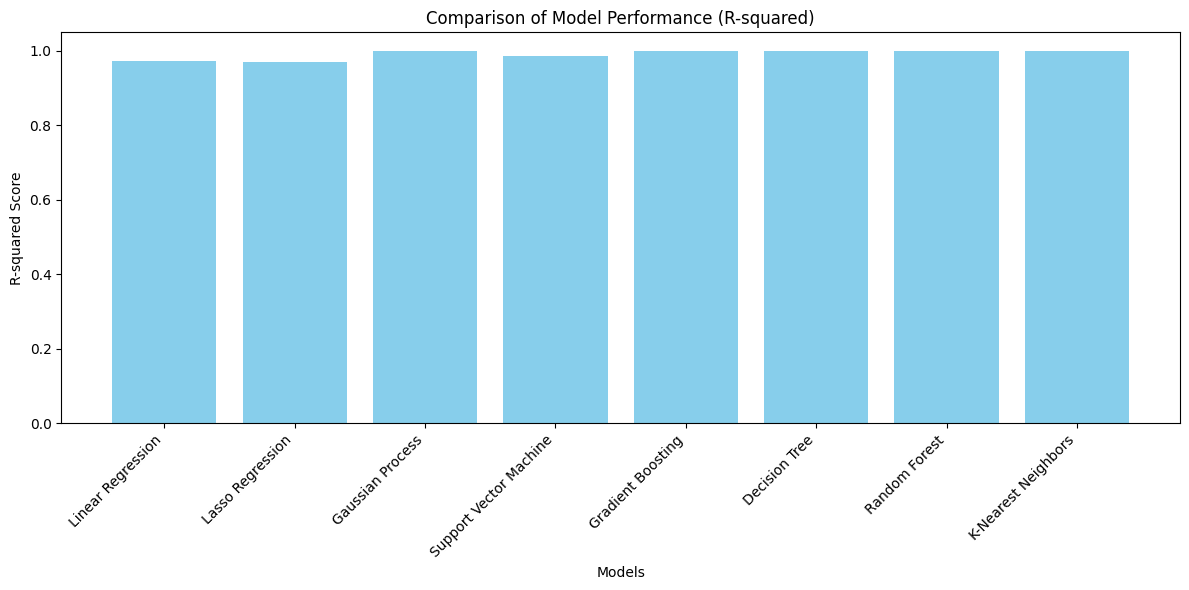

In [ ]:
# Train different models
resampled_models = {
    'Linear Regression': LinearRegression(),
    # 'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names_resampled = []
r2_scores_resampled = []
predictions_resampled = []

for name, resampled_model in resampled_models.items():
    resampled_model.fit(X_train_resampled_scaled, y_train_resampled)
    y_pred = resampled_model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores_resampled.append(r2)
    model_names_resampled.append(name)
    predictions_resampled.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names_resampled, r2_scores_resampled, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

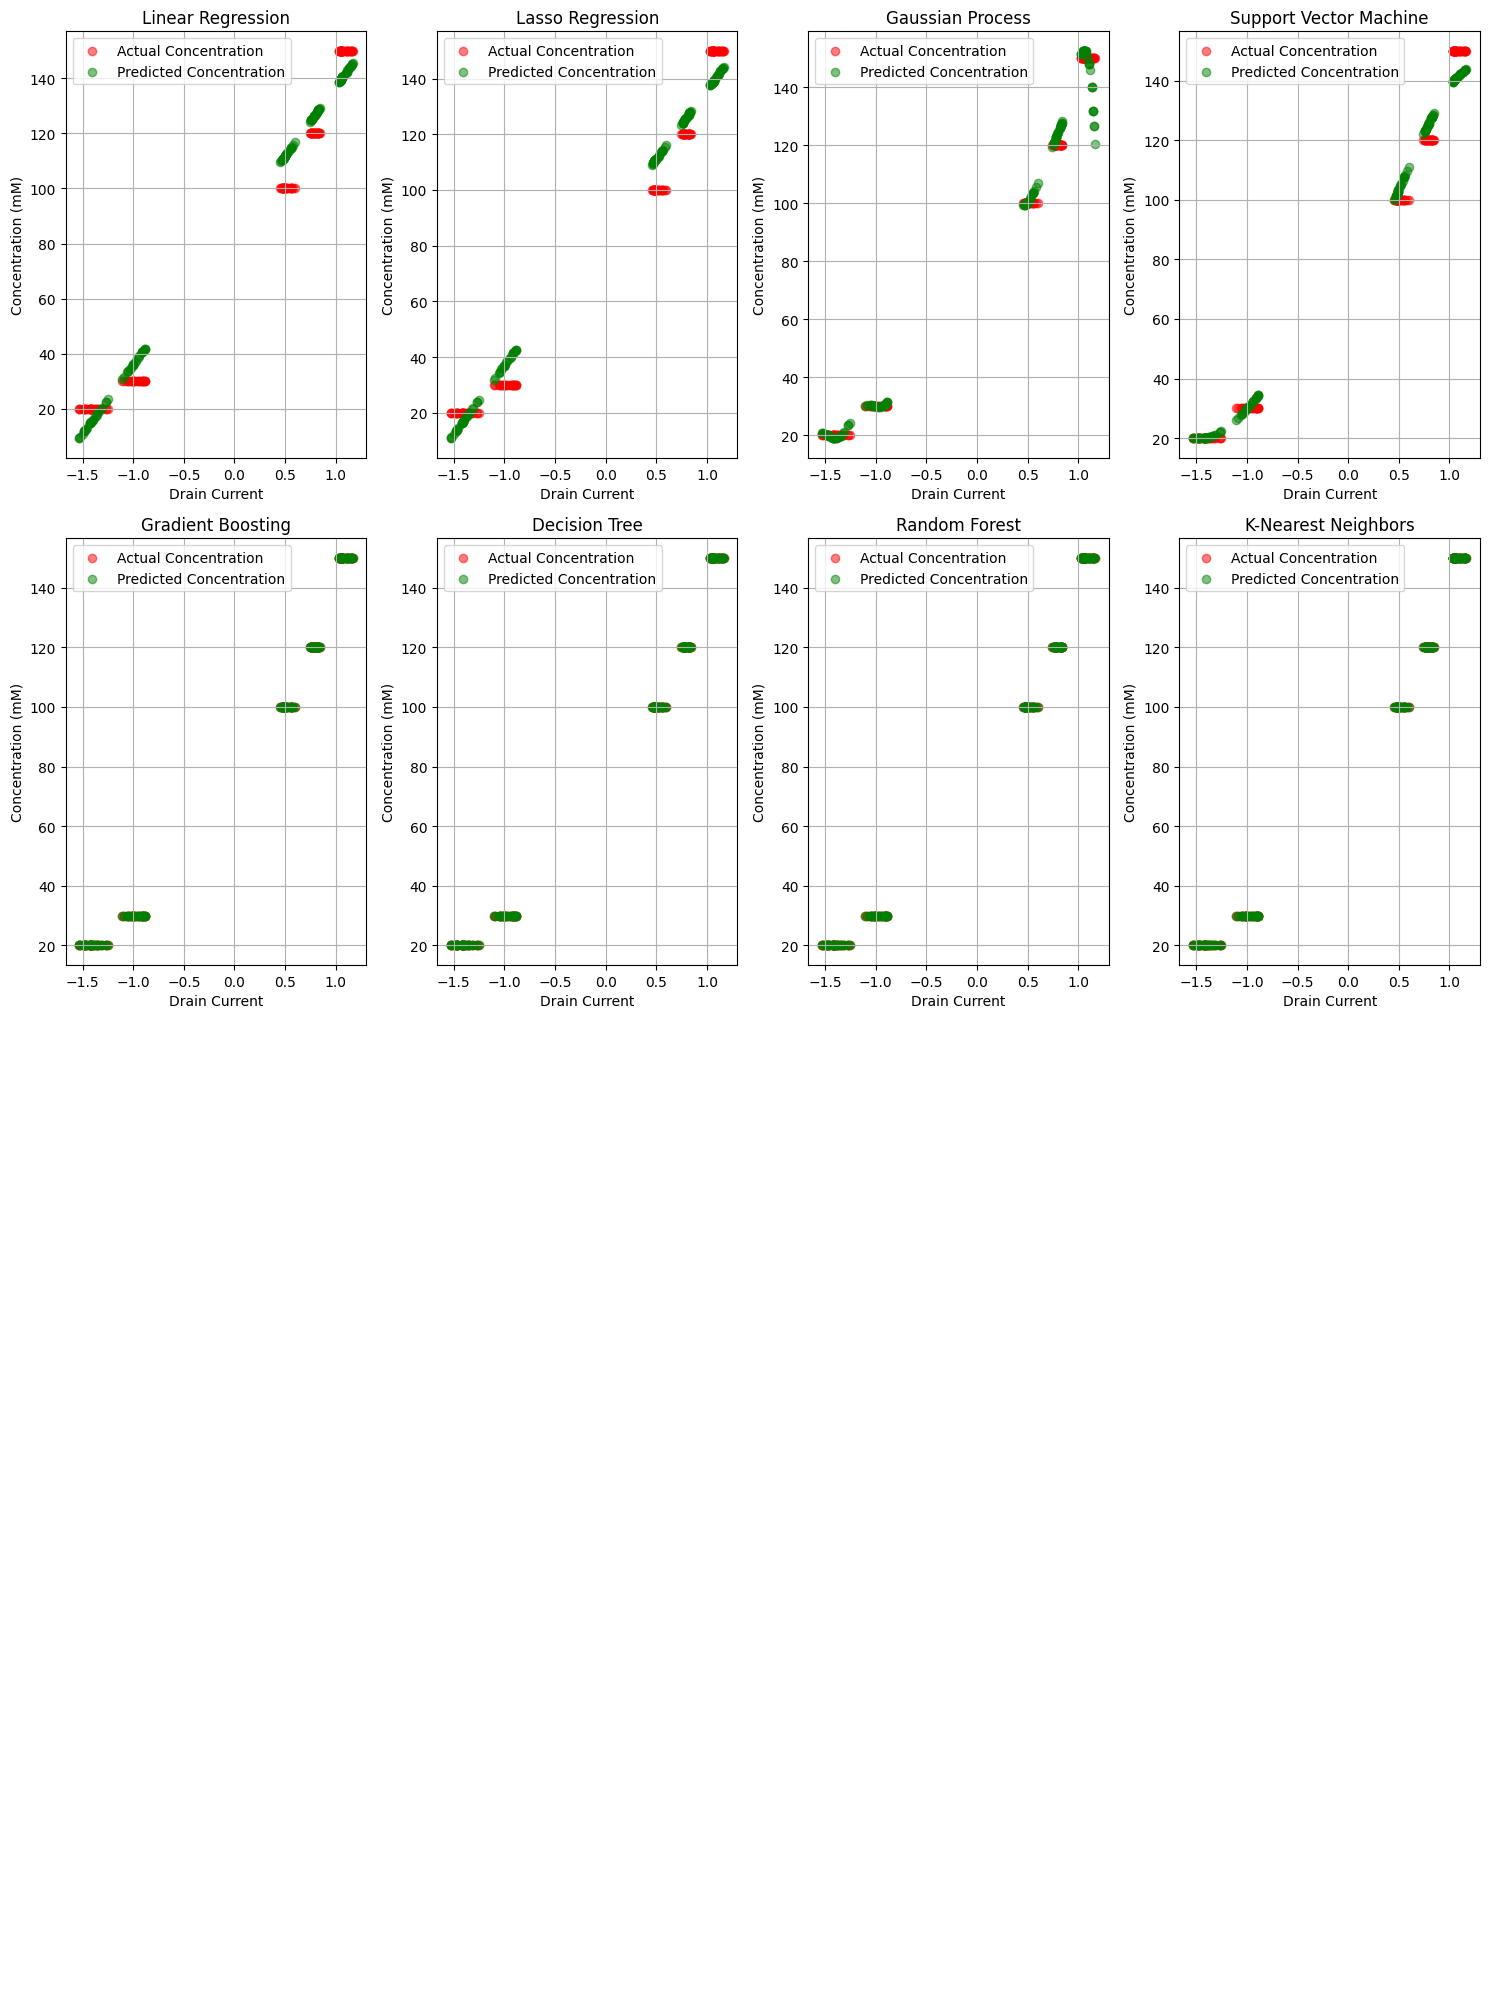

In [ ]:
num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=4, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[i]
    axes[i].scatter(X_test_scaled, y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_scaled, y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'{name}')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

####Calibration curves

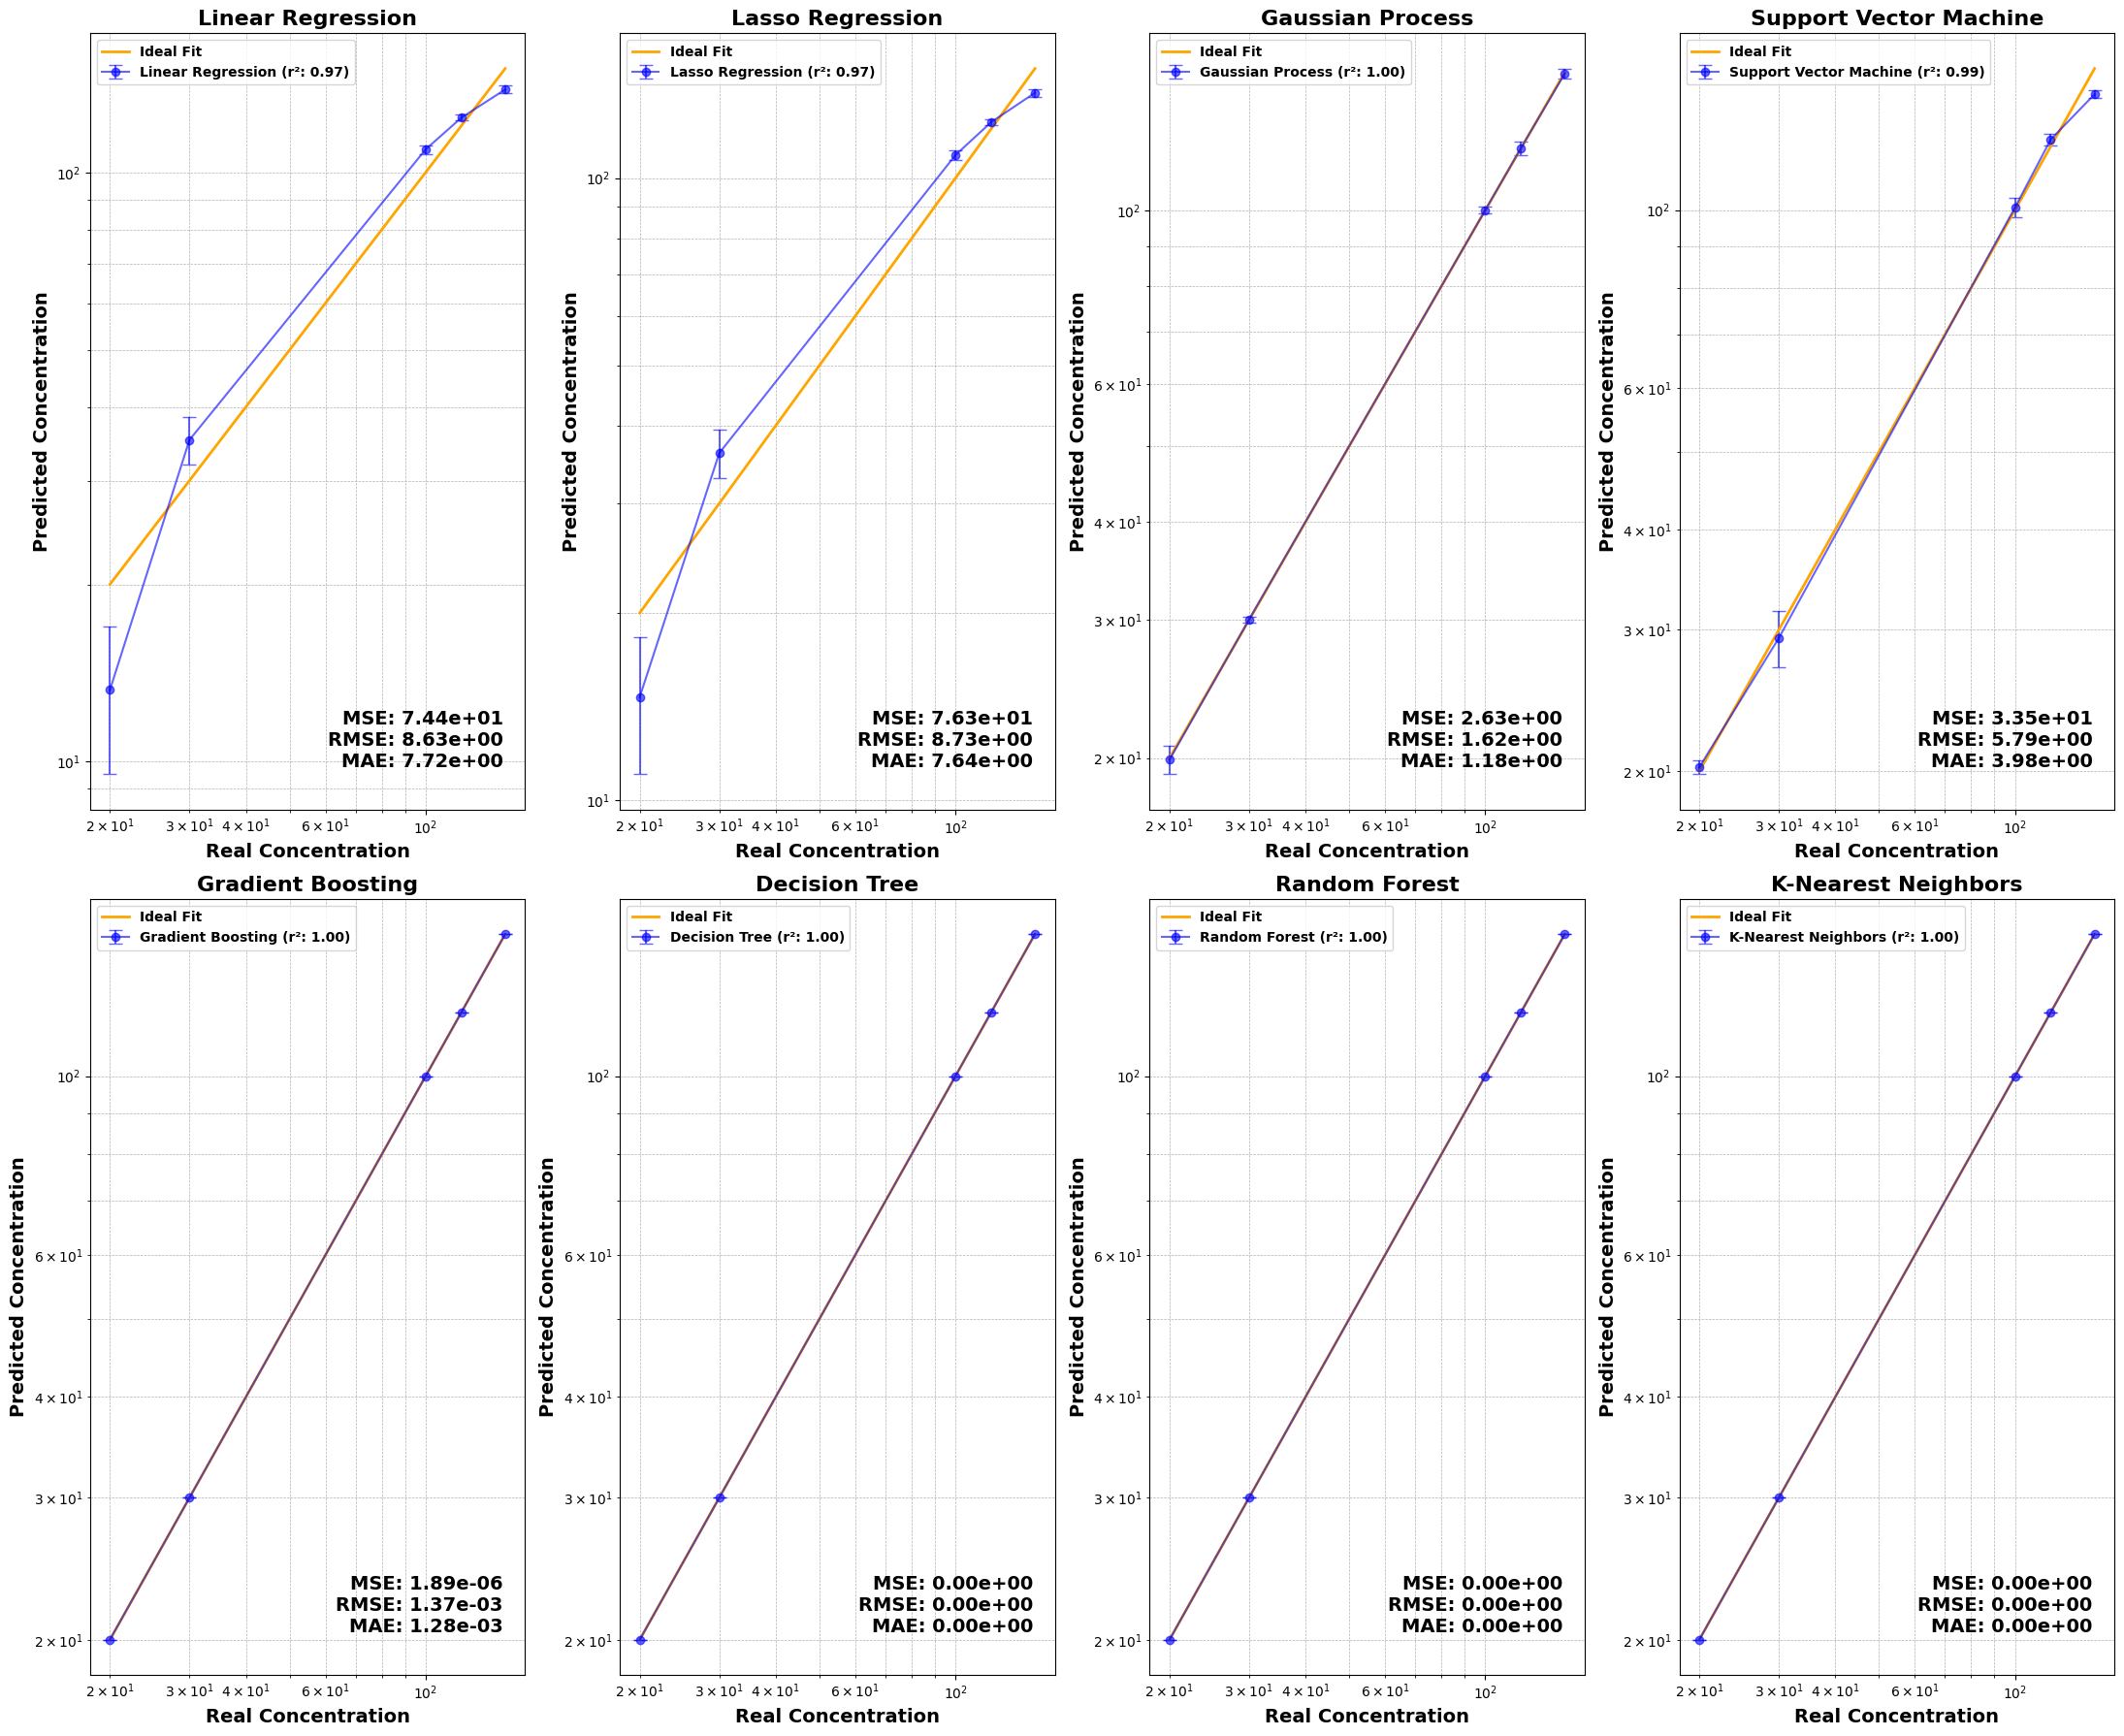

In [ ]:
import matplotlib.font_manager as fm

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 18))
axes = axes.flatten()

# Define the FontProperties for the legend
font_properties = fm.FontProperties(weight='bold')

for i, (name, y_pred) in enumerate(zip(model_names_resampled, predictions_resampled)):
    ax = axes[i]

    # Find unique concentrations in y_test
    unique_concentrations = np.unique(y_test)
    mean_predictions = []
    std_predictions = []

    # Calculate mean and std for each unique concentration
    for conc in unique_concentrations:
        mask = y_test == conc
        y_pred_for_conc = y_pred[mask]
        mean_predictions.append(np.mean(y_pred_for_conc))
        std_predictions.append(np.std(y_pred_for_conc))

    # Plot mean predictions with error bars (standard deviation)
    ax.errorbar(unique_concentrations, mean_predictions, yerr=std_predictions, fmt='o-', color='blue', alpha=0.6,
                label=f'{name} (r²: {r2_scores_resampled[i]:.2f})', capsize=5)

    # Plot ideal fit line (y = x)
    ax.plot(unique_concentrations, unique_concentrations, color='orange', linewidth=2, label='Ideal Fit')

    # Include metrics in the legend
    metrics_text = (f'MSE: {mean_squared_error(y_test, y_pred):.2e}\n'
                    f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2e}\n'
                    f'MAE: {mean_absolute_error(y_test, y_pred):.2e}')

    # Increased font size and bold for the metrics text
    ax.text(0.95, 0.05, metrics_text, transform=ax.transAxes, fontsize=14, fontweight='bold',
            verticalalignment='bottom', horizontalalignment='right')

    # Set axis to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Increase font size and bold for axis labels
    ax.set_xlabel('Real Concentration', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Concentration', fontsize=14, fontweight='bold')

    # Increase font size and bold for title
    ax.set_title(name, fontsize=16, fontweight='bold')

    # Use font_properties for the legend
    ax.legend(fontsize=12, prop=font_properties)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

####noise

In [ ]:
!pip install PyWavelets
import pywt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 29.4 MB/s eta 0:00:00


In [ ]:
np.random.seed(42)
# Create a noisy version of 'Drain Current'
noise_std = 0.000015  # Standard deviation of the noise
data['Noisy Drain Current'] = data['Drain Current'] + np.random.normal(0, noise_std, len(data))

# Perform wavelet denoising
# Adjust the wavelet_denoise function to match the original signal length
def wavelet_denoise(signal, wavelet='db4', level=4):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = noise_std
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs[1:] = (pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:])
    denoised_signal = pywt.waverec(coeffs, wavelet)

    # Adjust length if needed
    return denoised_signal[:len(signal)]

# Apply wavelet denoising to 'Noisy Drain Current' and ensure it matches the DataFrame length
data['Denoised Drain Current'] = wavelet_denoise(data['Noisy Drain Current'])

X = data[['Denoised Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test_noise_scaled = scaler.fit_transform(X)
y_test = y

Linear Regression:
Mean Squared Error: 85.90296241135906
Root Mean Squared Error: 9.26838510266805
Mean Absolute Error: 7.920618362157518
R-squared: 0.967292131973852
---
Lasso Regression:
Mean Squared Error: 86.77317320282435
Root Mean Squared Error: 9.315211924740325
Mean Absolute Error: 7.83374009969354
R-squared: 0.9669607960231094
---
Gaussian Process:
Mean Squared Error: 153.88199480302842
Root Mean Squared Error: 12.404918169944871
Mean Absolute Error: 3.426937031835206
R-squared: 0.9414088660468325
---
Support Vector Machine:
Mean Squared Error: 45.404881694583054
Root Mean Squared Error: 6.738314455008987
Mean Absolute Error: 4.701645805920426
R-squared: 0.9827119247518185
---
Gradient Boosting:
Mean Squared Error: 6.241623371765719
Root Mean Squared Error: 2.4983241126334508
Mean Absolute Error: 0.22595308908432388
R-squared: 0.9976234790072195
---
Decision Tree:
Mean Squared Error: 6.242197253433209
Root Mean Squared Error: 2.498438963319538
Mean Absolute Error: 0.2247191011

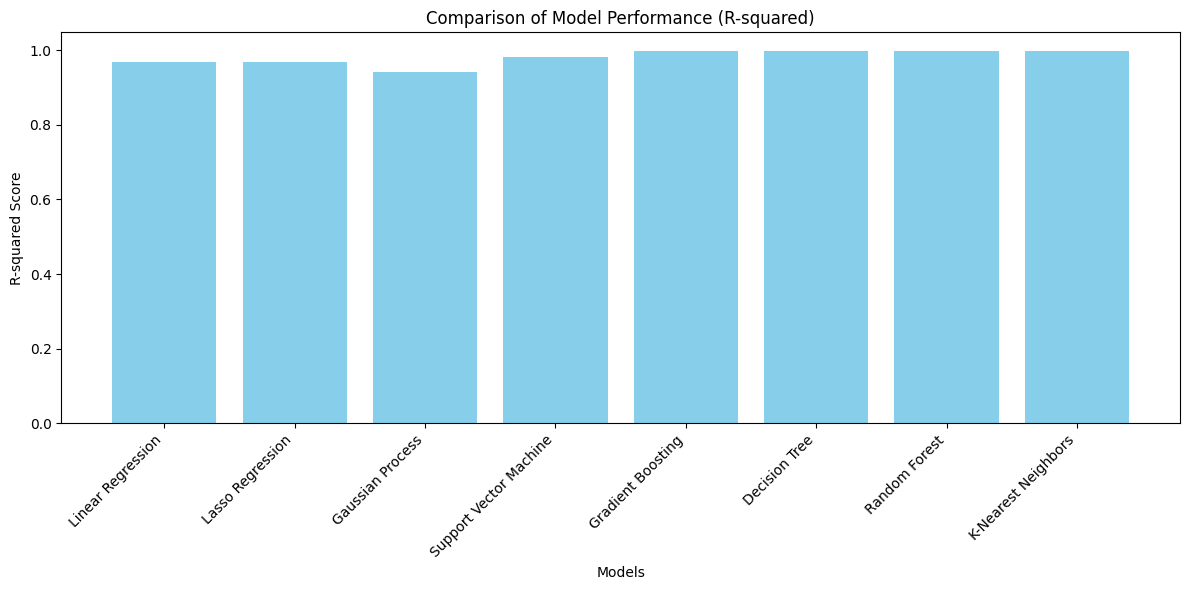

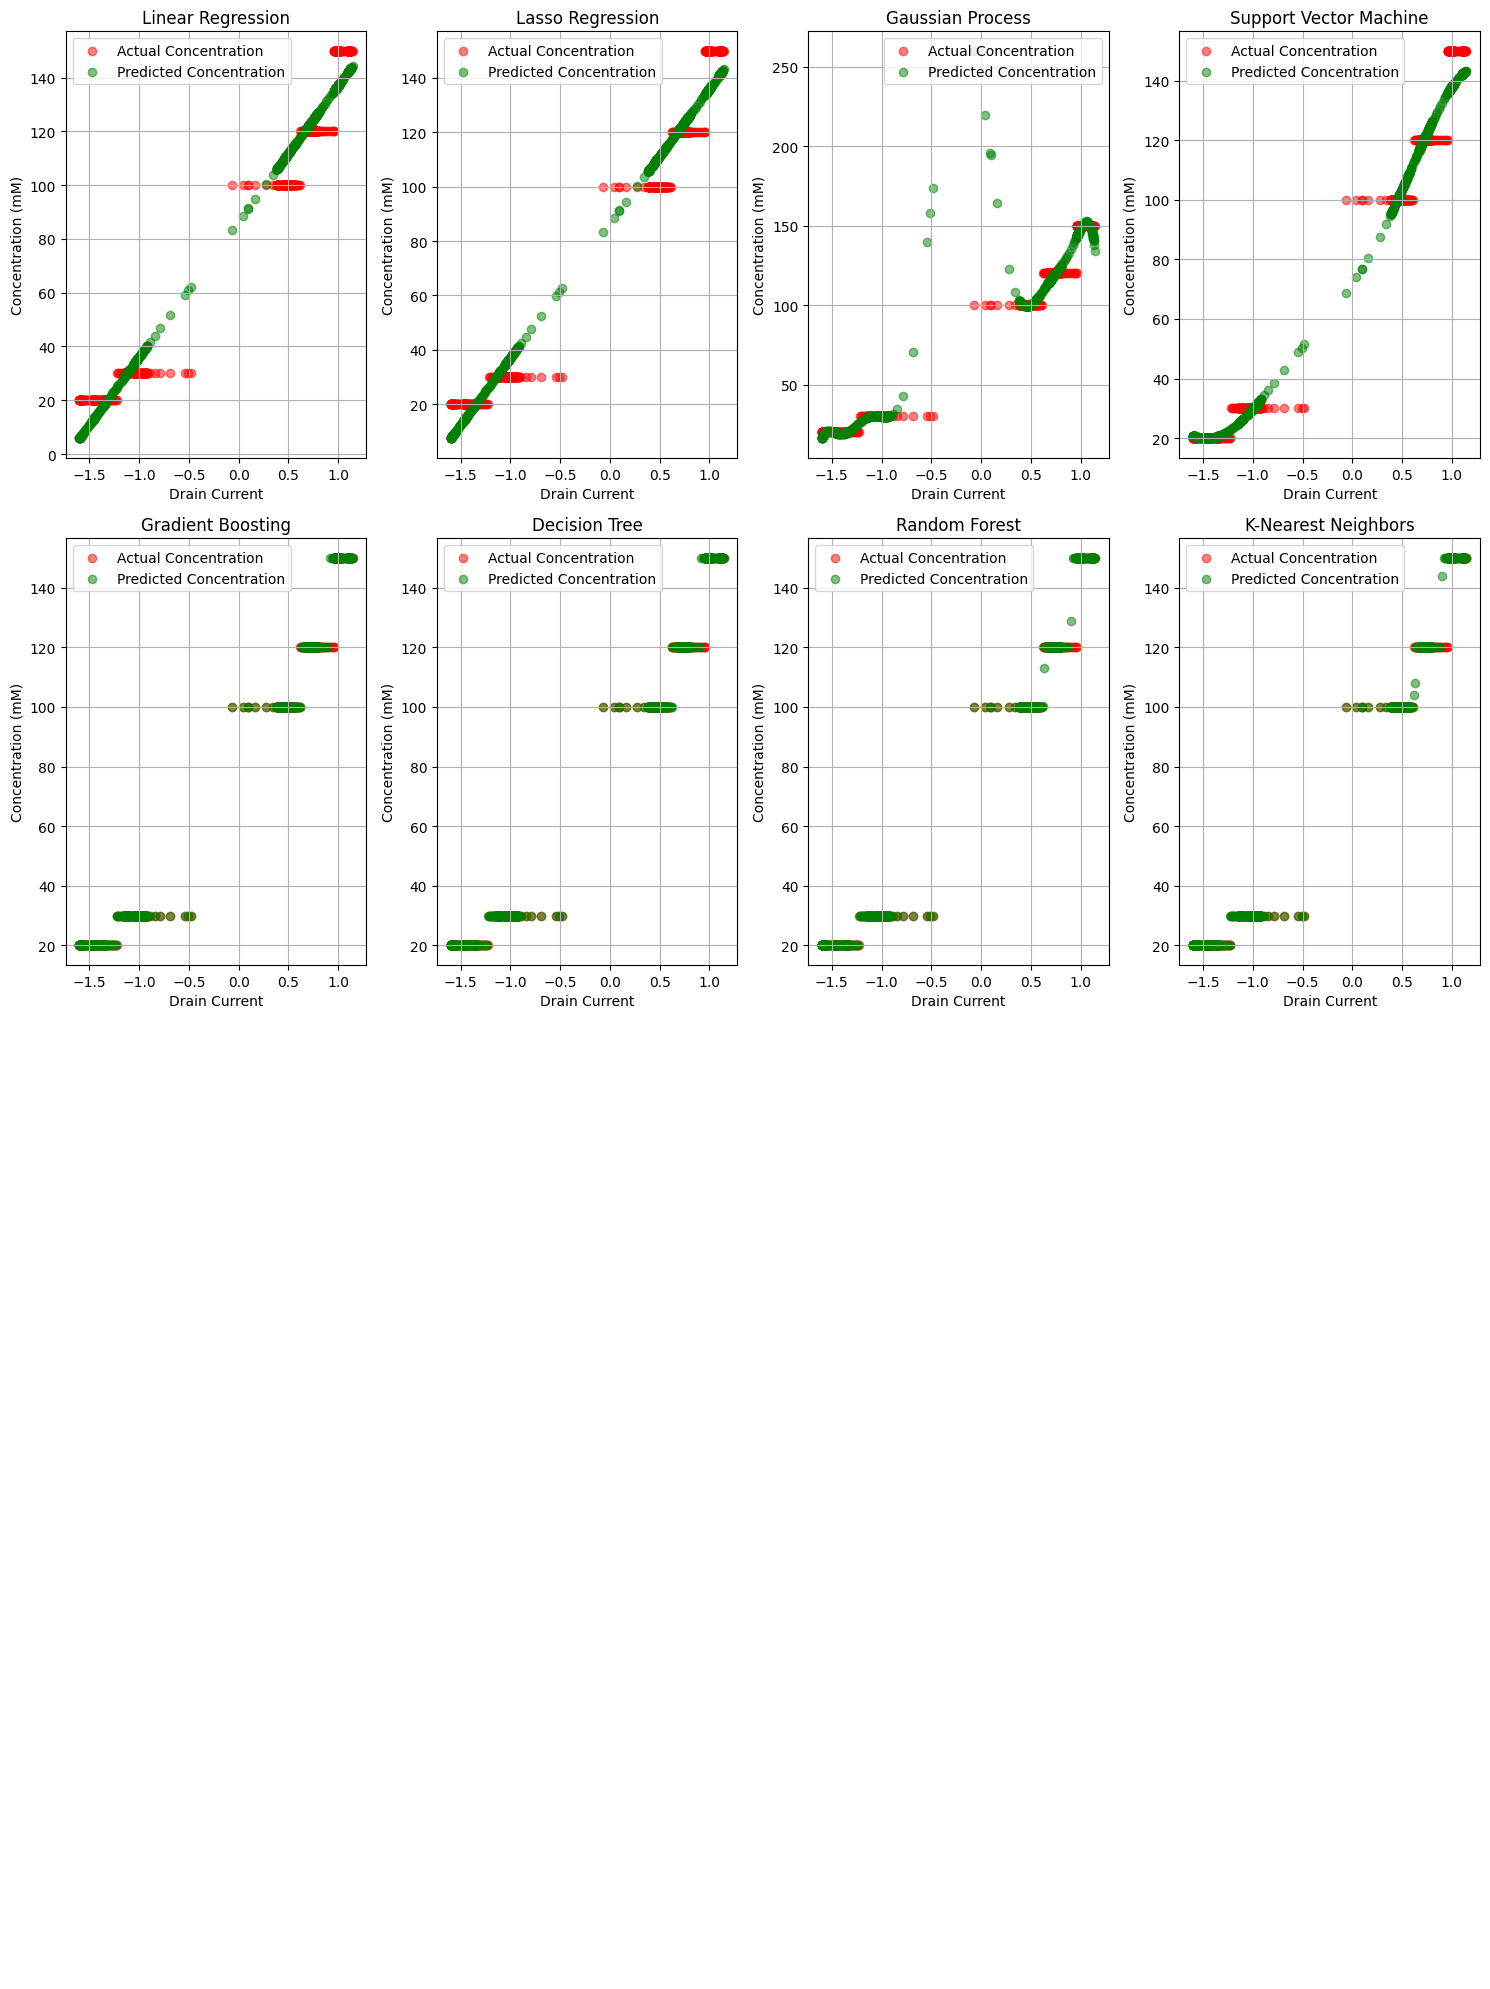

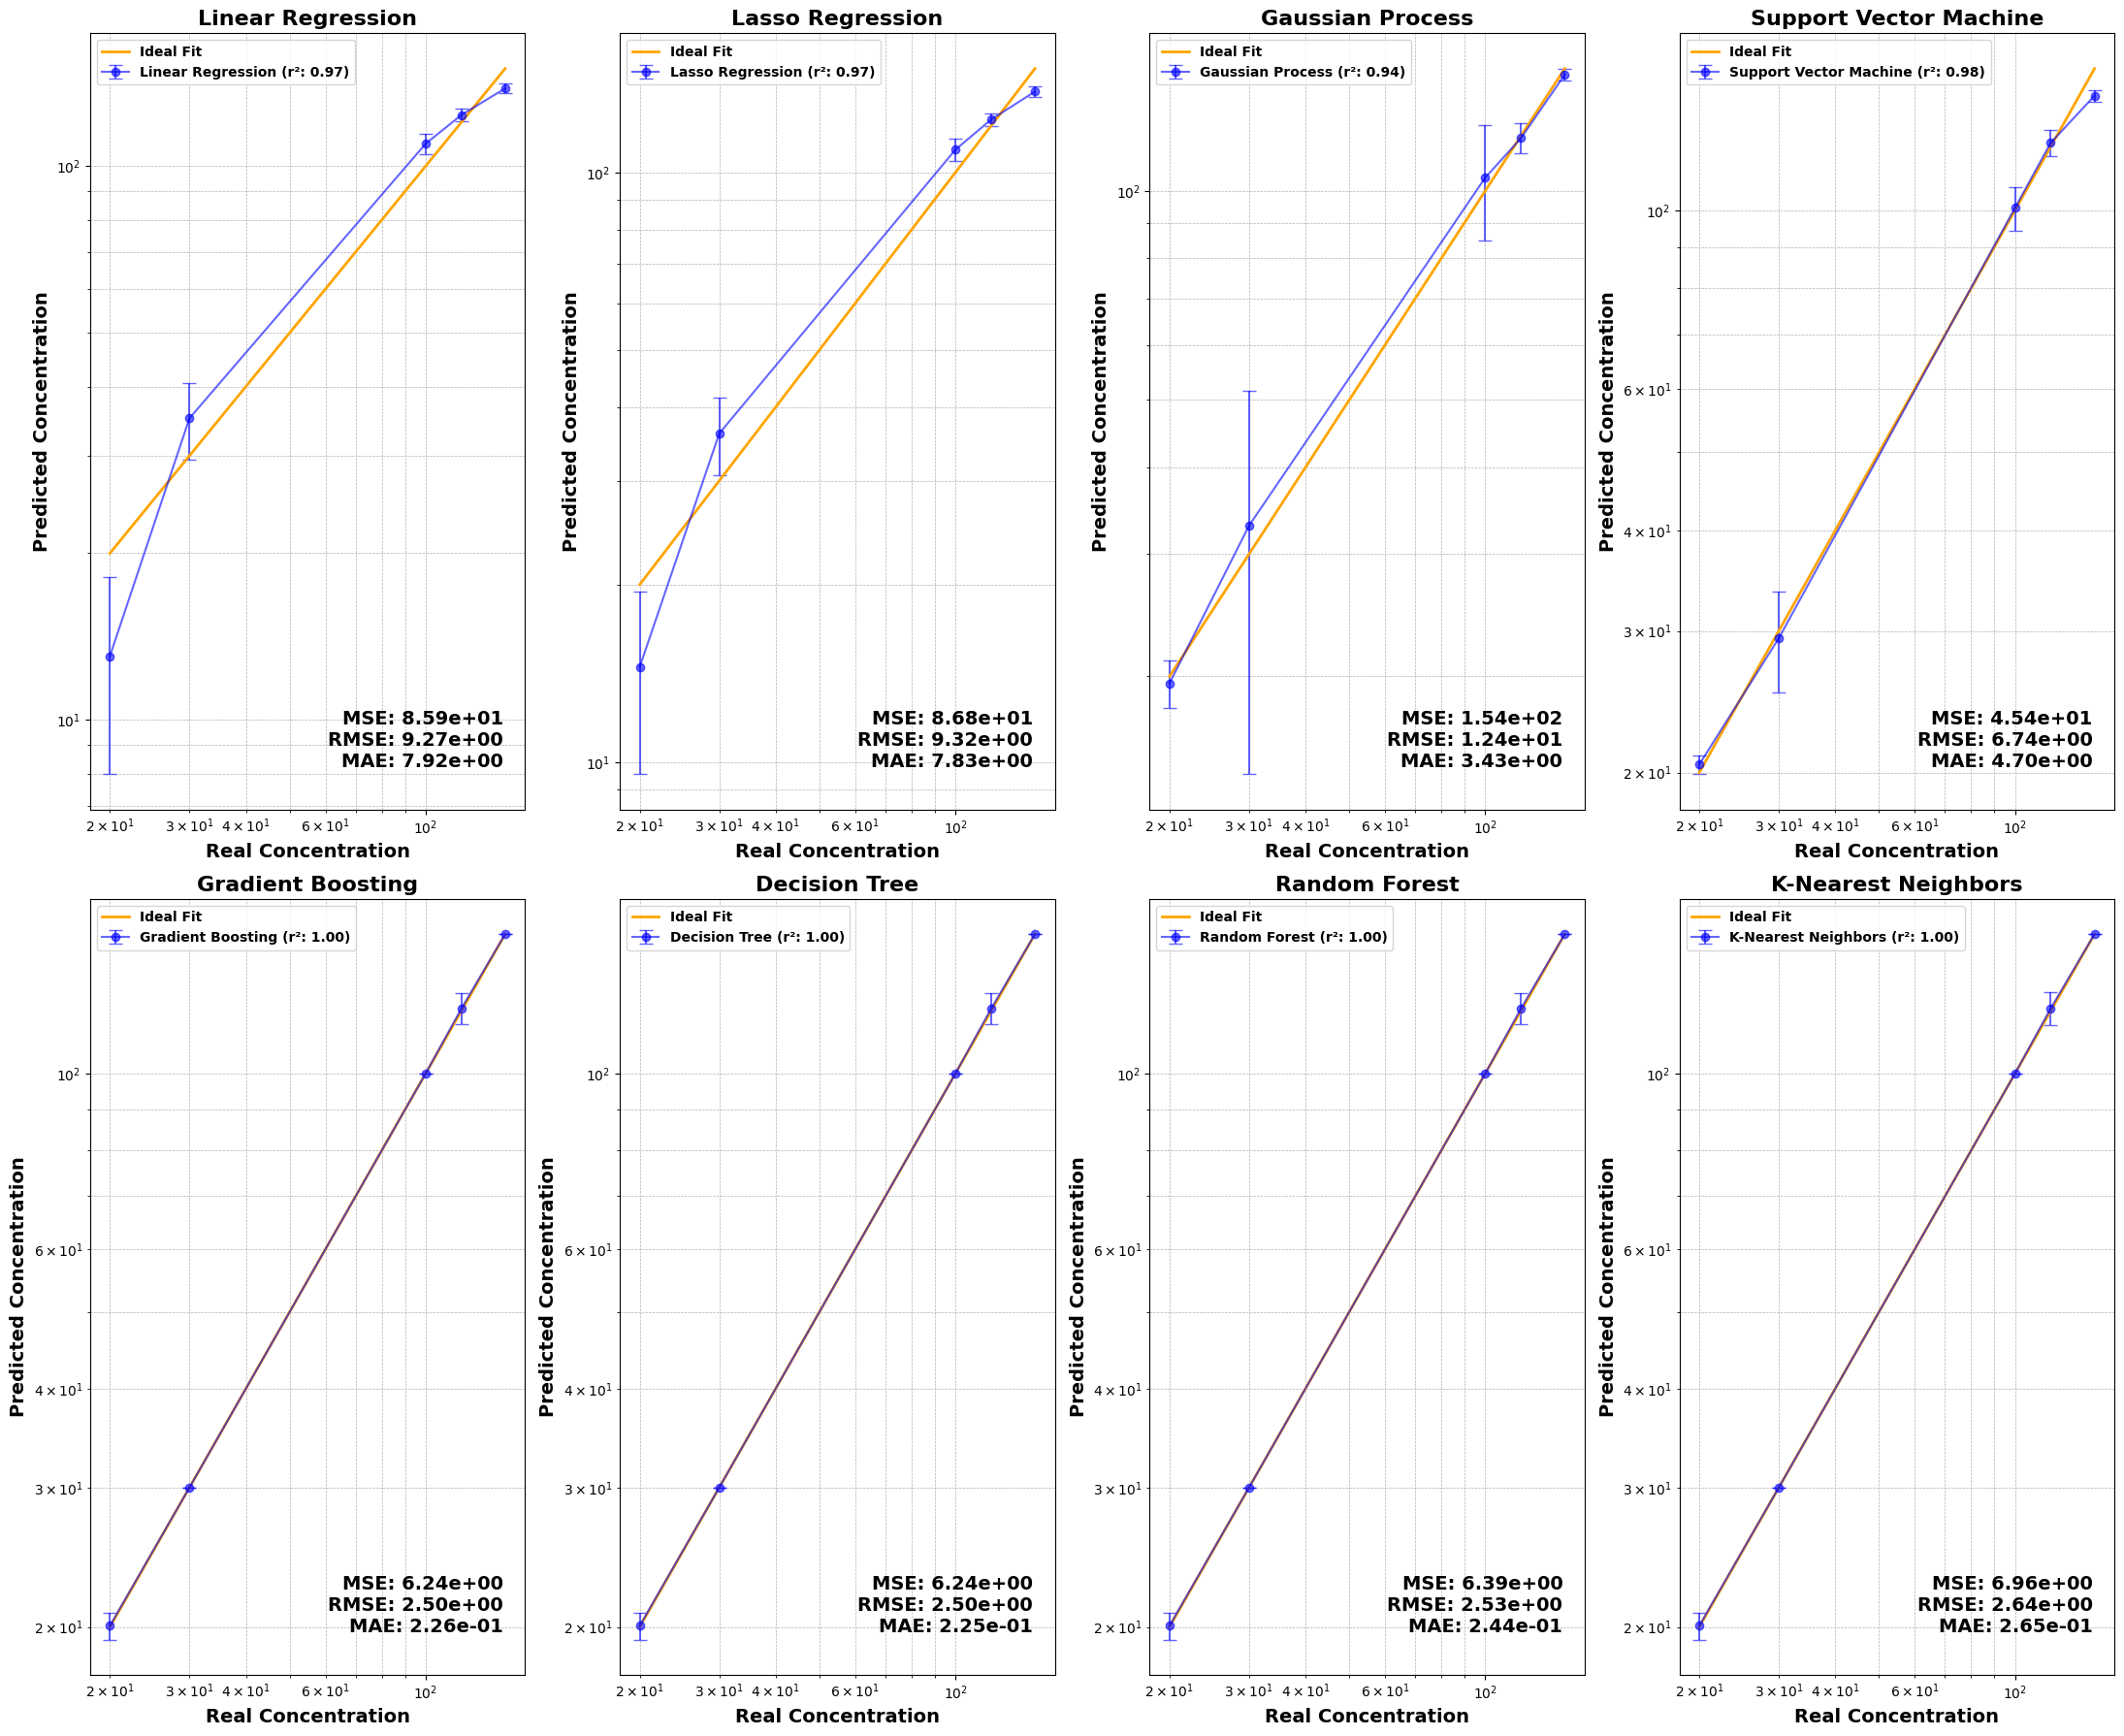

In [ ]:
model_names = []
r2_scores_noise = []
predictions_noise = []

for name, model in models.items():
    # model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_noise_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores_noise.append(r2)
    model_names.append(name)
    predictions_noise.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores_noise, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=4, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions_noise[i]
    axes[i].scatter(X_test_noise_scaled, y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_noise_scaled, y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'{name}')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(22, 18))
axes = axes.flatten()

# Define the FontProperties for the legend
font_properties = fm.FontProperties(weight='bold')

for i, (name, y_pred) in enumerate(zip(model_names, predictions_noise)):
    ax = axes[i]

    # Find unique concentrations in y_test
    unique_concentrations = np.unique(y_test)
    mean_predictions = []
    std_predictions = []

    # Calculate mean and std for each unique concentration
    for conc in unique_concentrations:
        mask = y_test == conc
        y_pred_for_conc = y_pred[mask]
        mean_predictions.append(np.mean(y_pred_for_conc))
        std_predictions.append(np.std(y_pred_for_conc))

    # Plot mean predictions with error bars (standard deviation)
    ax.errorbar(unique_concentrations, mean_predictions, yerr=std_predictions, fmt='o-', color='blue', alpha=0.6,
                label=f'{name} (r²: {r2_scores_noise[i]:.2f})', capsize=5)

    # Plot ideal fit line (y = x)
    ax.plot(unique_concentrations, unique_concentrations, color='orange', linewidth=2, label='Ideal Fit')

    # Include metrics in the legend
    metrics_text = (f'MSE: {mean_squared_error(y_test, y_pred):.2e}\n'
                    f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2e}\n'
                    f'MAE: {mean_absolute_error(y_test, y_pred):.2e}')

    # Increased font size and bold for the metrics text
    ax.text(0.95, 0.05, metrics_text, transform=ax.transAxes, fontsize=14, fontweight='bold',
            verticalalignment='bottom', horizontalalignment='right')

    # Set axis to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Increase font size and bold for axis labels
    ax.set_xlabel('Real Concentration', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Concentration', fontsize=14, fontweight='bold')

    # Increase font size and bold for title
    ax.set_title(name, fontsize=16, fontweight='bold')

    # Use font_properties for the legend
    ax.legend(fontsize=12, prop=font_properties)

    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# With Gate Voltage and Drain Current

Linear Regression:
Mean Squared Error: 73.75728564987669
Root Mean Squared Error: 8.588206195118786
Mean Absolute Error: 7.793364001299307
R-squared: 0.9721373499822137
---
Ridge Regression:
Mean Squared Error: 73.77446928894756
Root Mean Squared Error: 8.589206557590028
Mean Absolute Error: 7.786677592212092
R-squared: 0.9721308586679354
---
Lasso Regression:
Mean Squared Error: 74.9062041709472
Root Mean Squared Error: 8.654837038959613
Mean Absolute Error: 7.714278445278213
R-squared: 0.9717033329984068
---
Gaussian Process:
Mean Squared Error: 2.597265927414793
Root Mean Squared Error: 1.6116035267443396
Mean Absolute Error: 1.1666613750576234
R-squared: 0.9990188533796891
---
Support Vector Machine:
Mean Squared Error: 32.6973992021135
Root Mean Squared Error: 5.718163971251043
Mean Absolute Error: 3.944134061331216
R-squared: 0.9876481871257439
---
Gradient Boosting:
Mean Squared Error: 1.8724823737227666e-06
Root Mean Squared Error: 0.0013683867778237142
Mean Absolute Error: 0.0

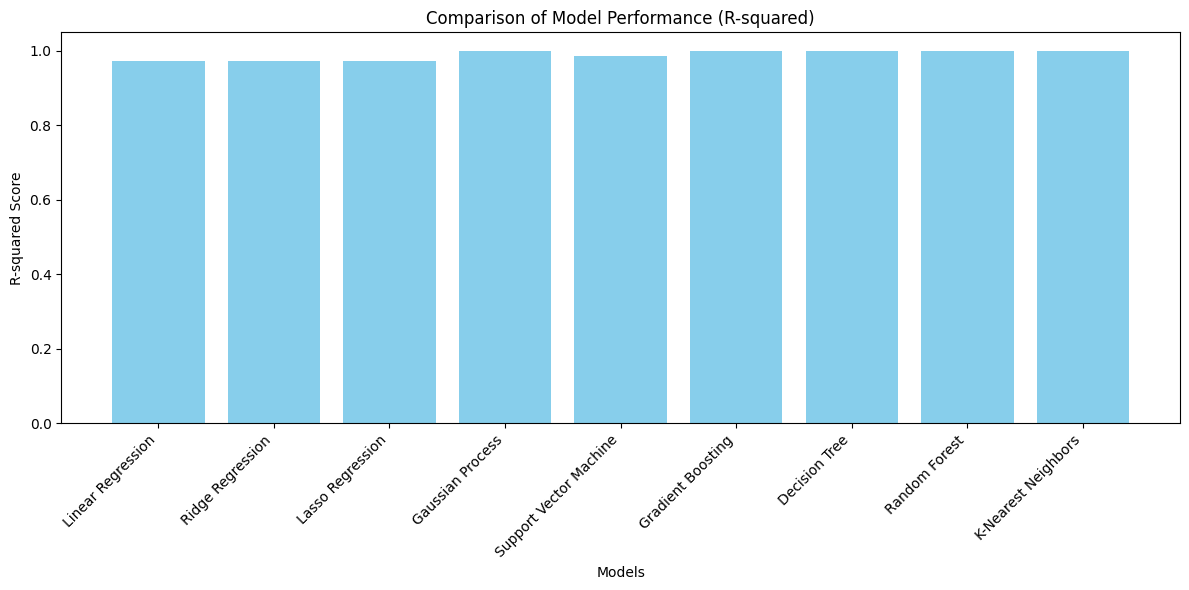

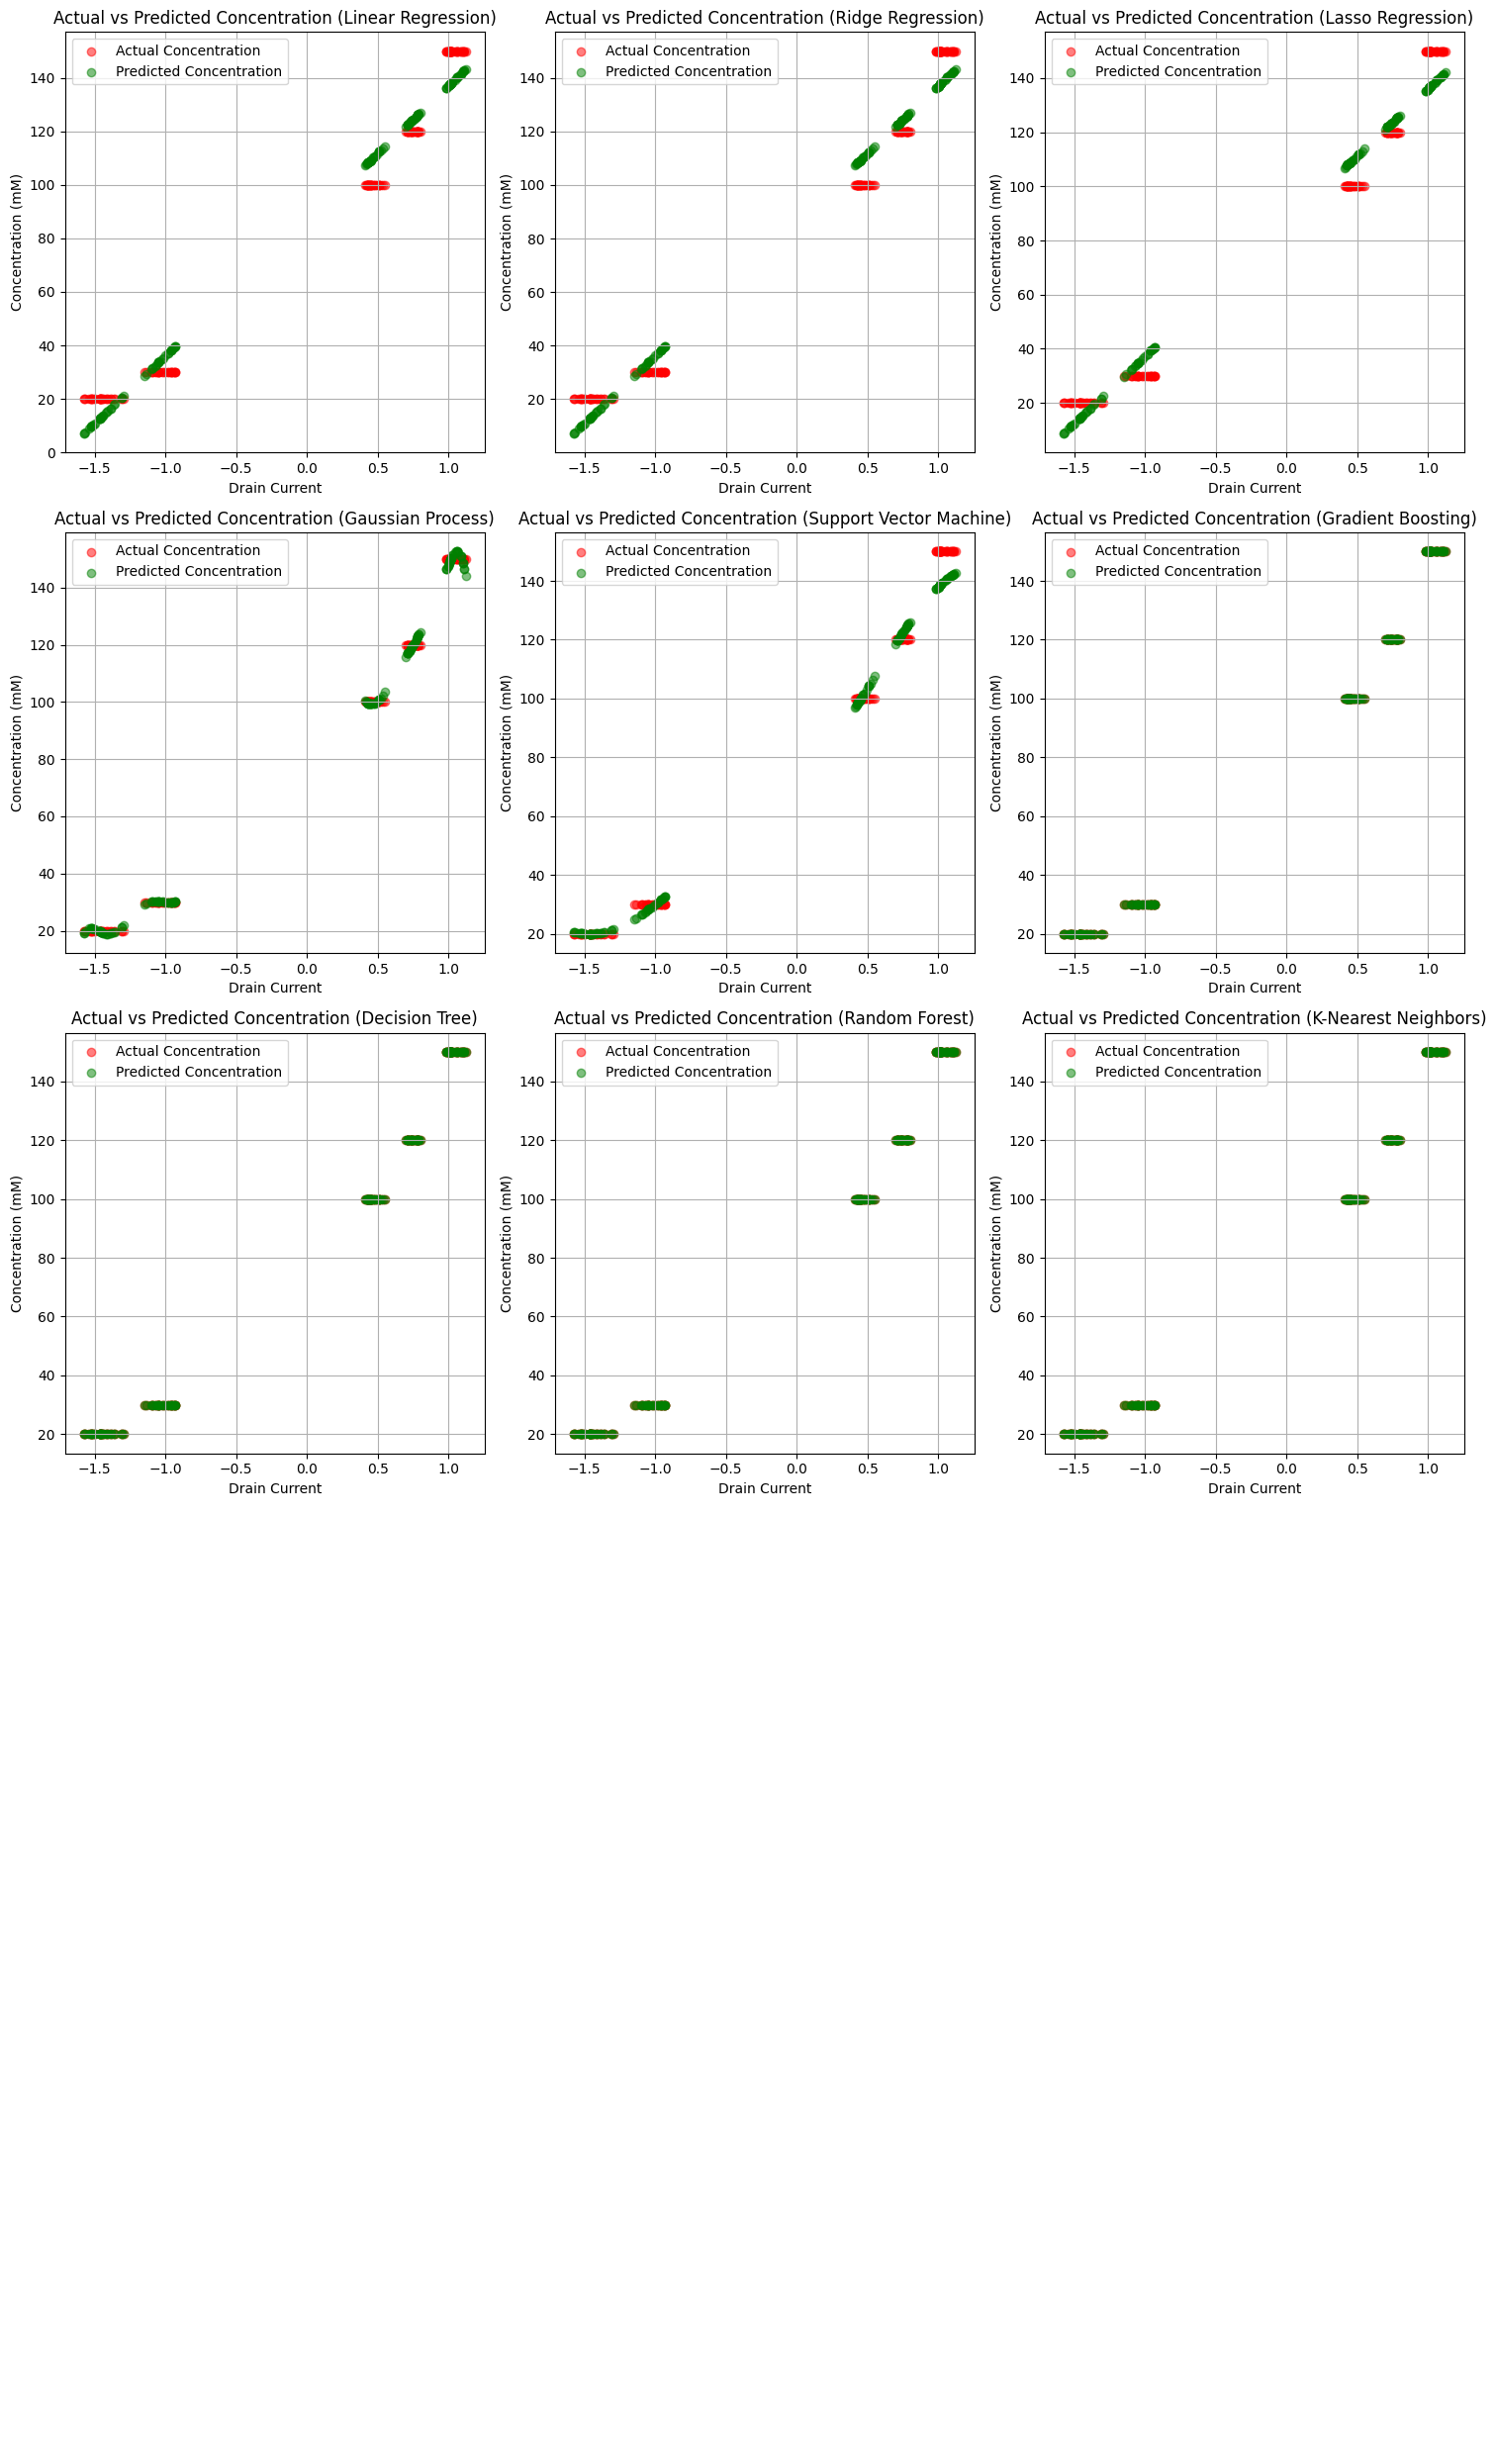

In [ ]:
X = data[['Gate Voltage','Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from imblearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train different models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names = []
r2_scores = []
predictions = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    model_names.append(name)
    predictions.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=3, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[i]
    axes[i].scatter(X_test_scaled[:,1], y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_scaled[:,1], y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'Actual vs Predicted Concentration ({name})')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#With Gate Time and Drain Current

Linear Regression:
Mean Squared Error: 72.3897034462701
Root Mean Squared Error: 8.508213881083979
Mean Absolute Error: 7.8874192296149
R-squared: 0.9726539696486494
---
Ridge Regression:
Mean Squared Error: 72.40788957605331
Root Mean Squared Error: 8.509282553544294
Mean Absolute Error: 7.87804482823622
R-squared: 0.9726470996321505
---
Lasso Regression:
Mean Squared Error: 73.70385493220122
Root Mean Squared Error: 8.585094928549202
Mean Absolute Error: 7.724583183934379
R-squared: 0.9721575340409635
---
Gaussian Process:
Mean Squared Error: 0.08826550639392758
Root Mean Squared Error: 0.2970951133794152
Mean Absolute Error: 0.17756563202934975
R-squared: 0.9999666567052783
---
Support Vector Machine:
Mean Squared Error: 145.20030155545896
Root Mean Squared Error: 12.049908777889522
Mean Absolute Error: 7.555882378162888
R-squared: 0.9451489415713936
---
Gradient Boosting:
Mean Squared Error: 1.8724823737149572e-06
Root Mean Squared Error: 0.0013683867778208605
Mean Absolute Error: 

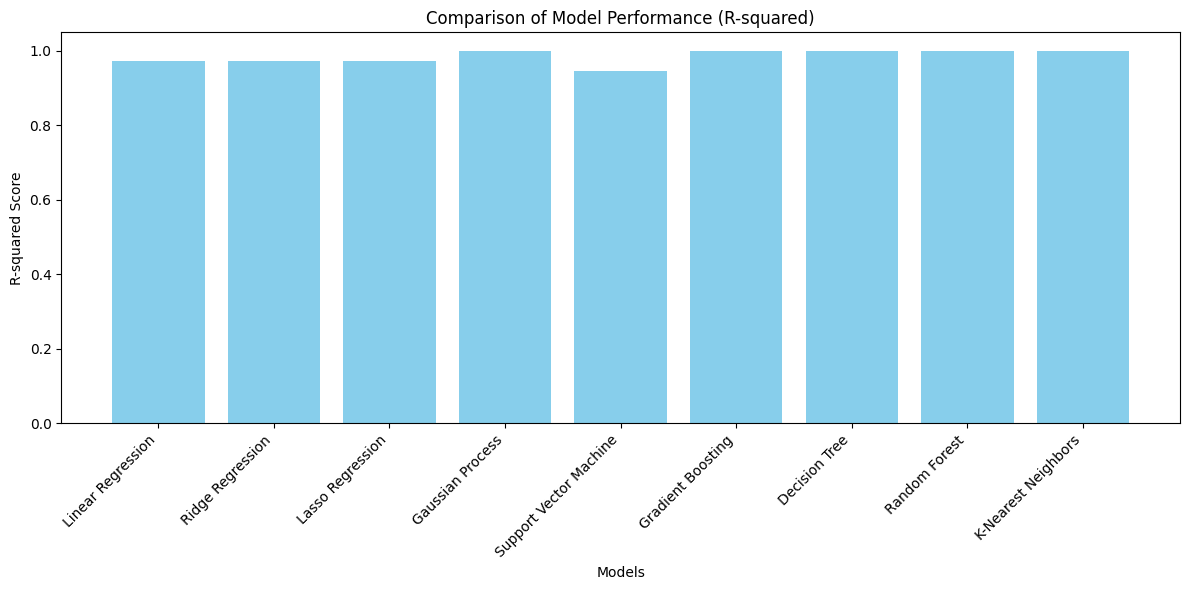

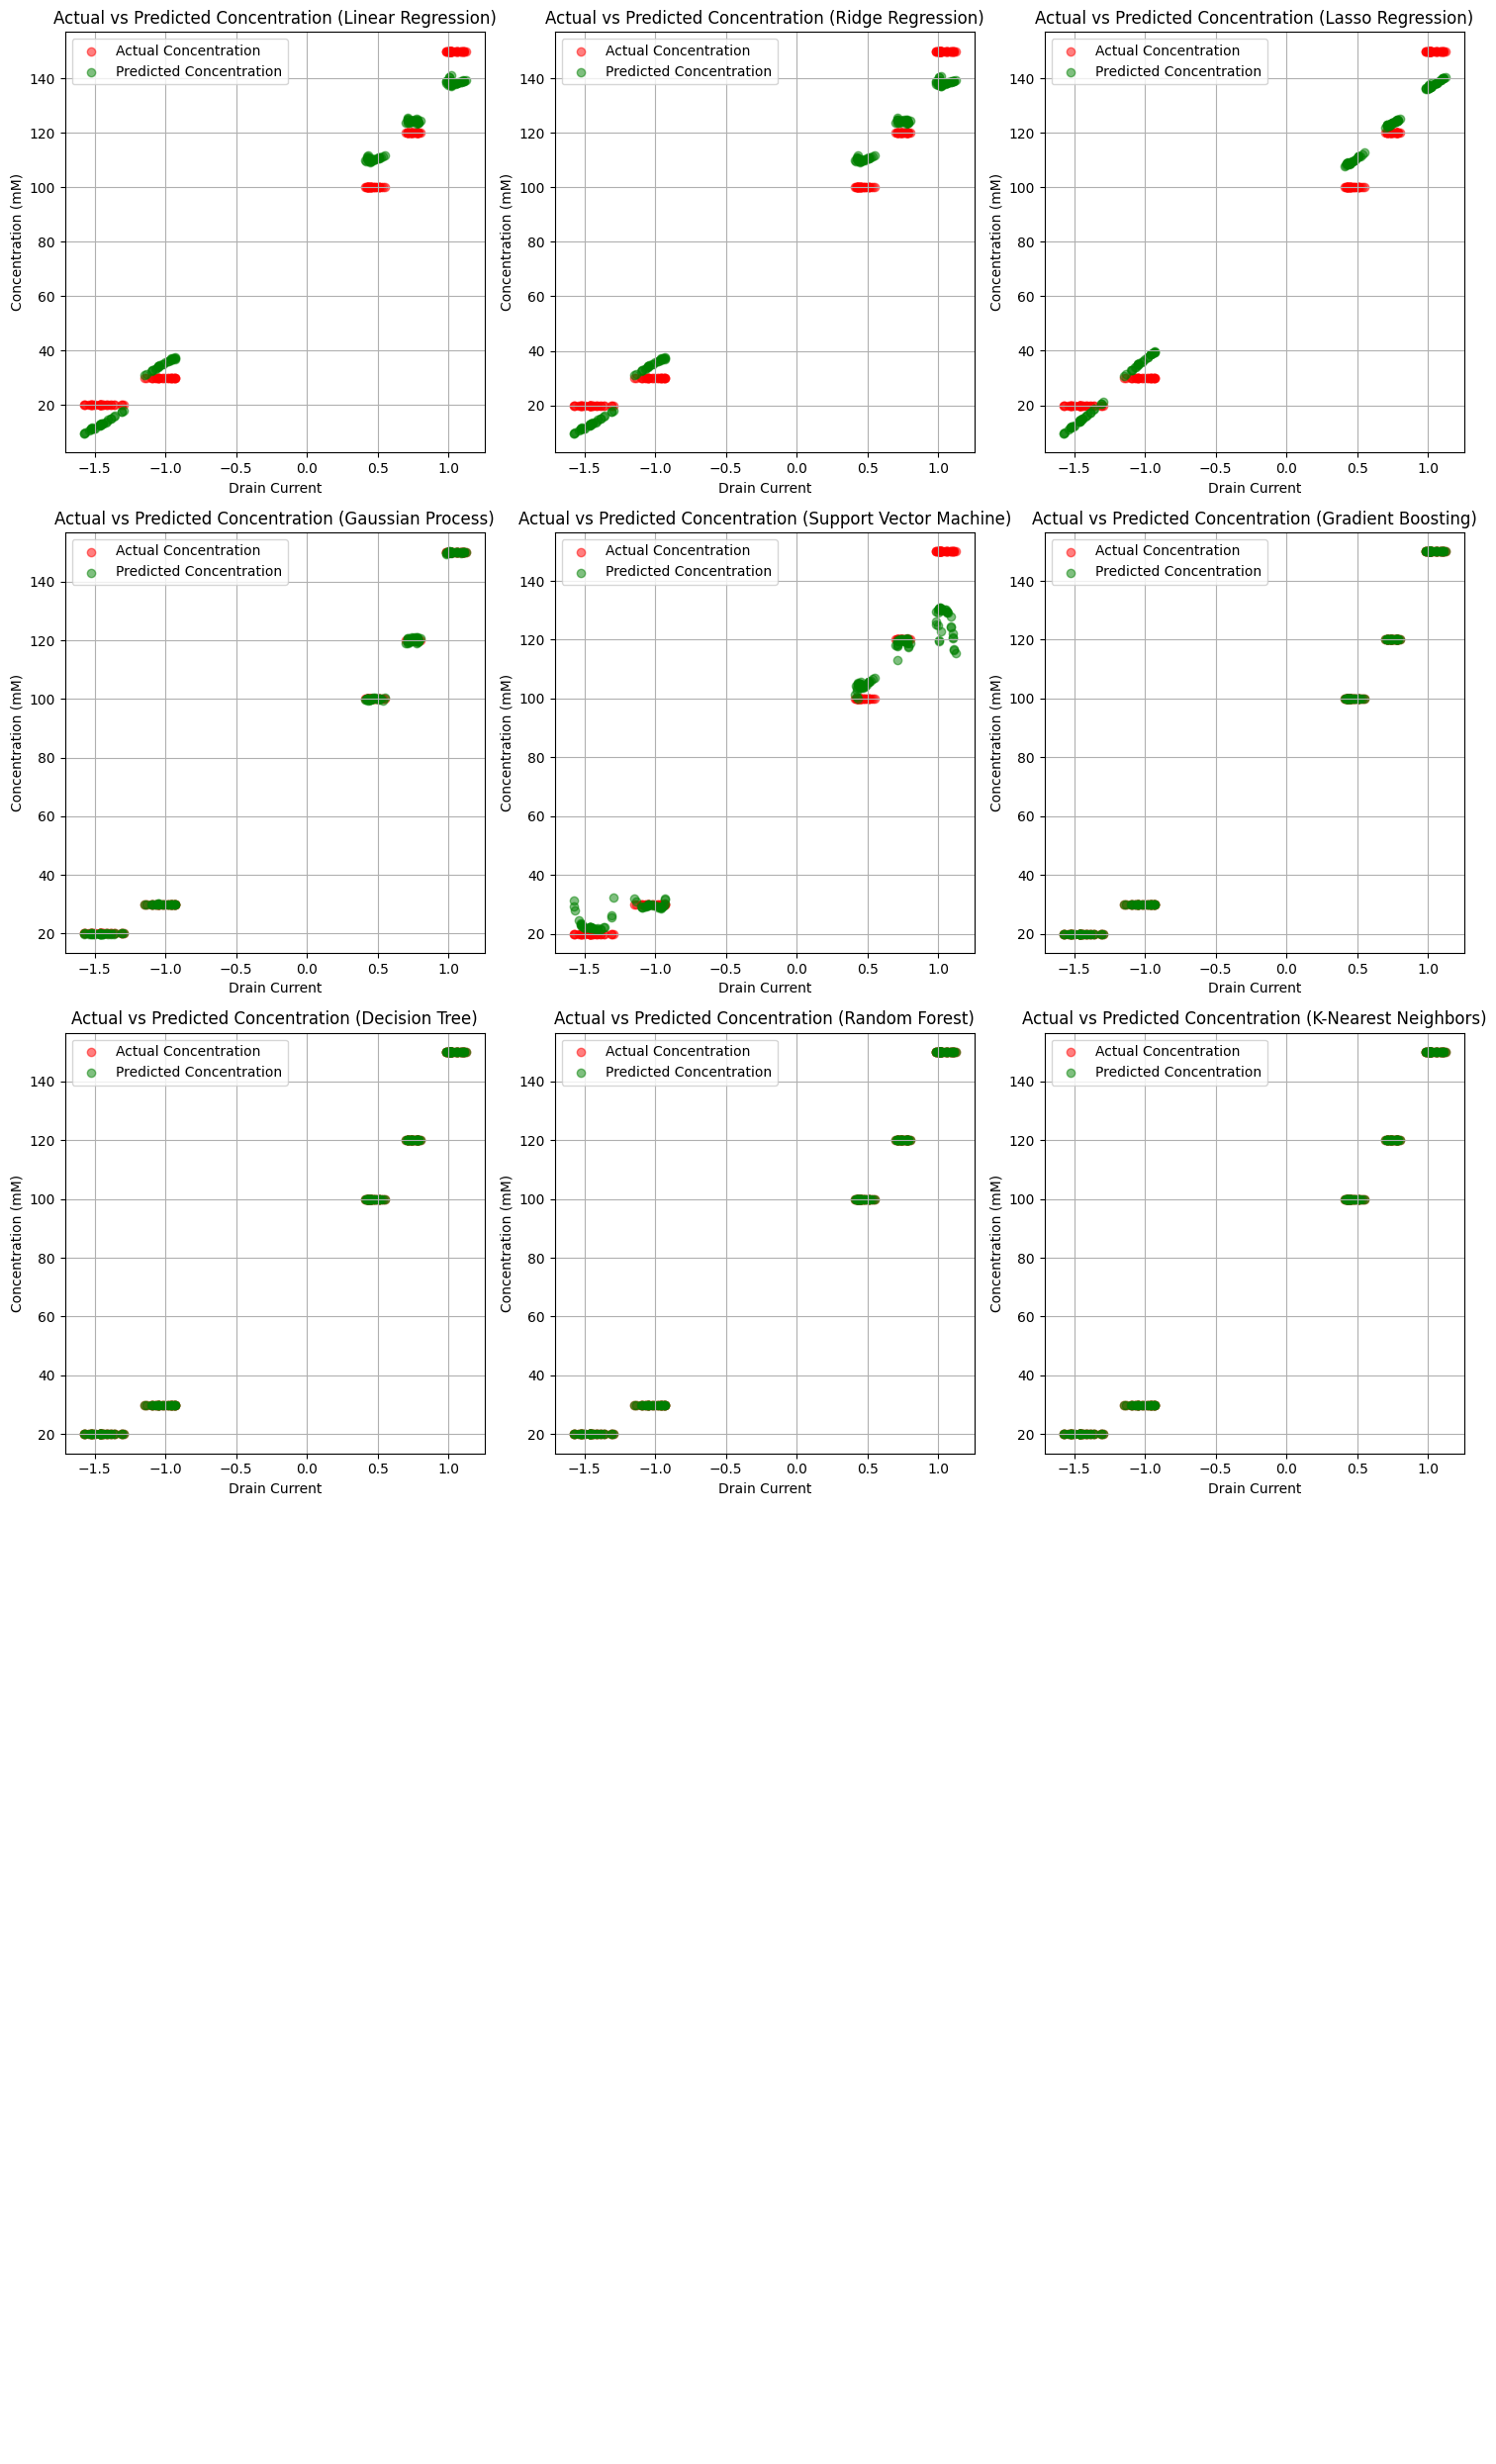

In [ ]:
X = data[['Gate Time','Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from imblearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train different models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names = []
r2_scores = []
predictions = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    model_names.append(name)
    predictions.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=3, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[i]
    axes[i].scatter(X_test_scaled[:,1], y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_scaled[:,1], y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'Actual vs Predicted Concentration ({name})')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#With ALL- Gate Voltage, Gate Time, Drain Current

Linear Regression:
Mean Squared Error: 72.3897034462701
Root Mean Squared Error: 8.508213881083979
Mean Absolute Error: 7.8874192296149
R-squared: 0.9726539696486494
---
Ridge Regression:
Mean Squared Error: 72.40788957605326
Root Mean Squared Error: 8.509282553544292
Mean Absolute Error: 7.87804482823622
R-squared: 0.9726470996321505
---
Lasso Regression:
Mean Squared Error: 73.70385493220122
Root Mean Squared Error: 8.585094928549202
Mean Absolute Error: 7.724583183934379
R-squared: 0.9721575340409635
---
Gaussian Process:
Mean Squared Error: 0.08826550639392758
Root Mean Squared Error: 0.2970951133794152
Mean Absolute Error: 0.17756563202934975
R-squared: 0.9999666567052783
---
Support Vector Machine:
Mean Squared Error: 145.20030155545896
Root Mean Squared Error: 12.049908777889522
Mean Absolute Error: 7.555882378162888
R-squared: 0.9451489415713936
---
Gradient Boosting:
Mean Squared Error: 1.8724823737258198e-06
Root Mean Squared Error: 0.0013683867778248296
Mean Absolute Error: 

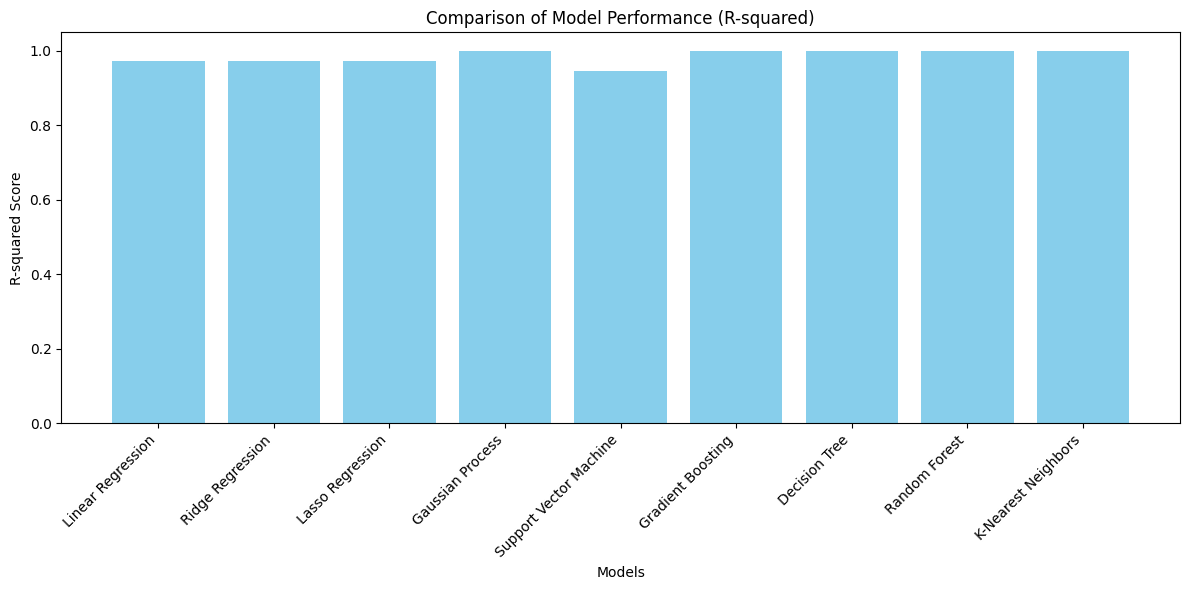

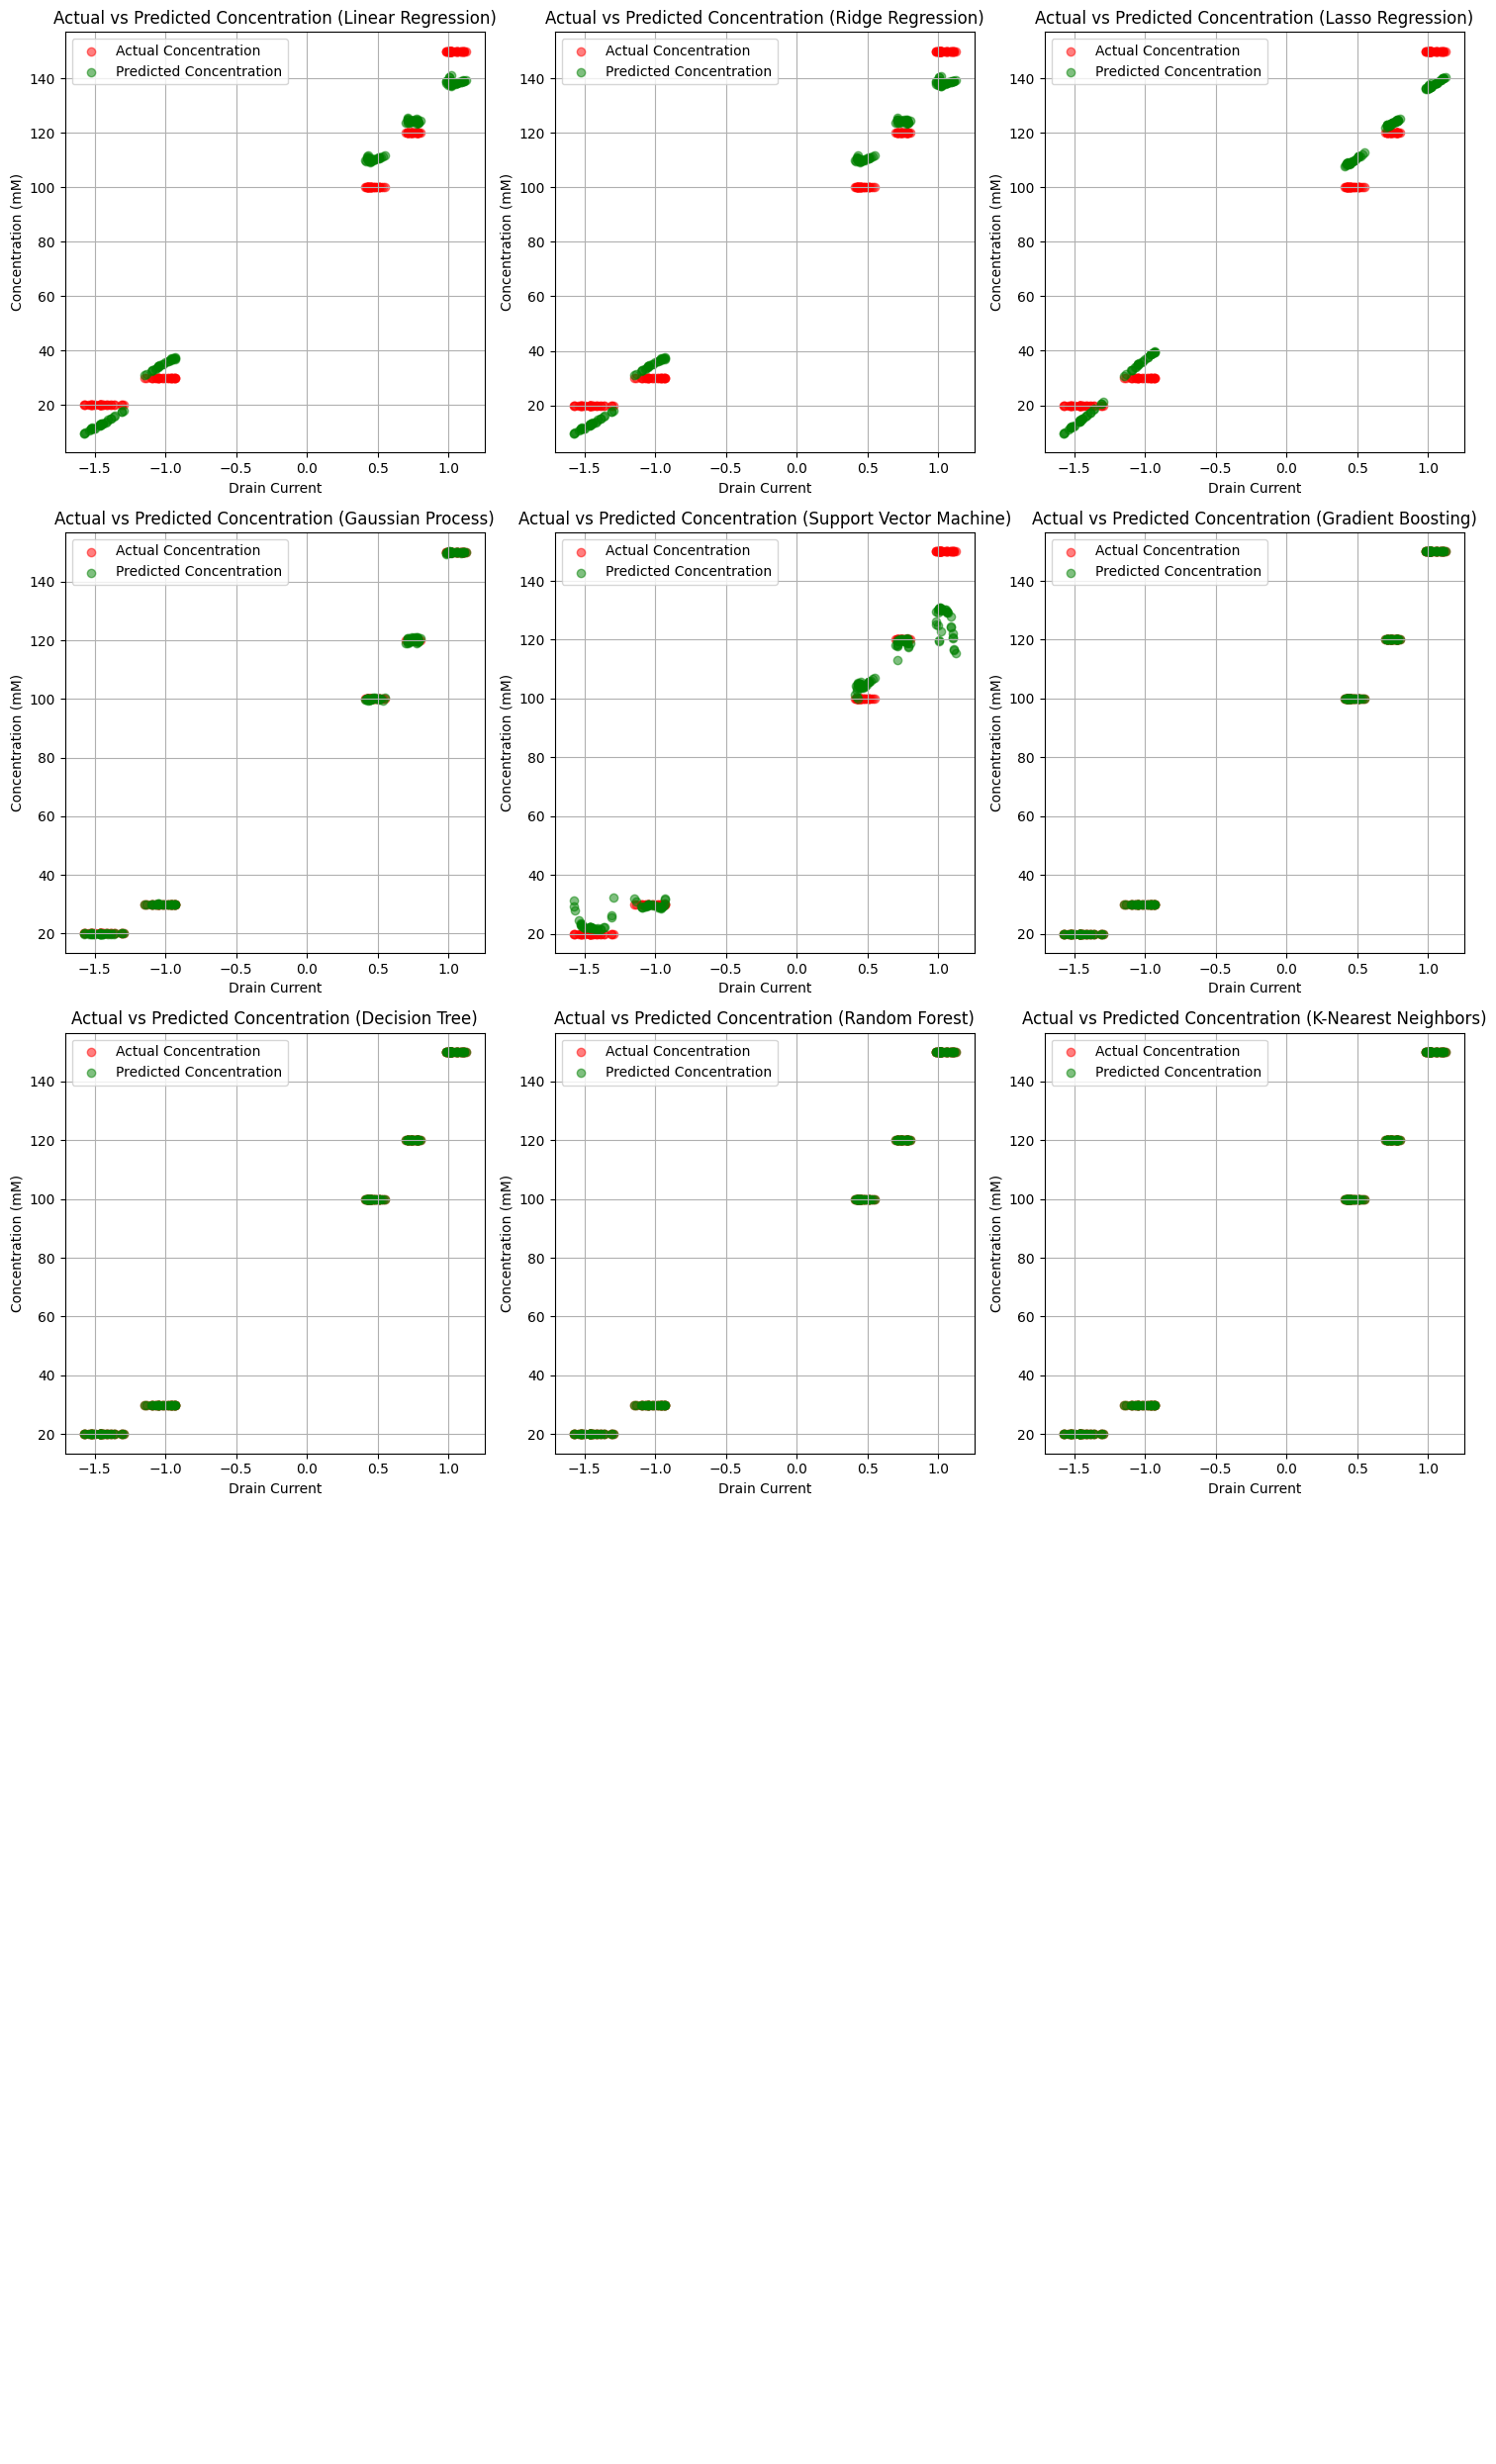

In [ ]:
X = data[['Gate Voltage','Gate Time','Drain Current']]  # Features
y = data['Concentration (mM)']  # Target variable

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from imblearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train different models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Gaussian Process': GaussianProcessRegressor(),
    'Support Vector Machine': SVR(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

model_names = []
r2_scores = []
predictions = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE from MSE
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)
    model_names.append(name)
    predictions.append(y_pred)

    print(f'{name}:')
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Squared Error: {rmse}') # Changed label to reflect RMSE
    print(f'Mean Absolute Error: {mae}')
    print(f'R-squared: {r2}')
    print('---')

# Create the comparison plot
plt.figure(figsize=(12, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("Models")
plt.ylabel("R-squared Score")
plt.title("Comparison of Model Performance (R-squared)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

num_models = len(models)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=3, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, (name, model) in enumerate(models.items()):
    y_pred = predictions[i]
    axes[i].scatter(X_test_scaled[:,2], y_test, color='red', label='Actual Concentration', alpha=0.5)
    axes[i].scatter(X_test_scaled[:,2], y_pred, color='green', label='Predicted Concentration', alpha=0.5)
    axes[i].set_xlabel('Drain Current')
    axes[i].set_ylabel('Concentration (mM)')
    axes[i].set_title(f'Actual vs Predicted Concentration ({name})')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Unsupervised Algorithms

In [ ]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

#WITH ALL - Gate Voltage, Gate Time and Drain Current

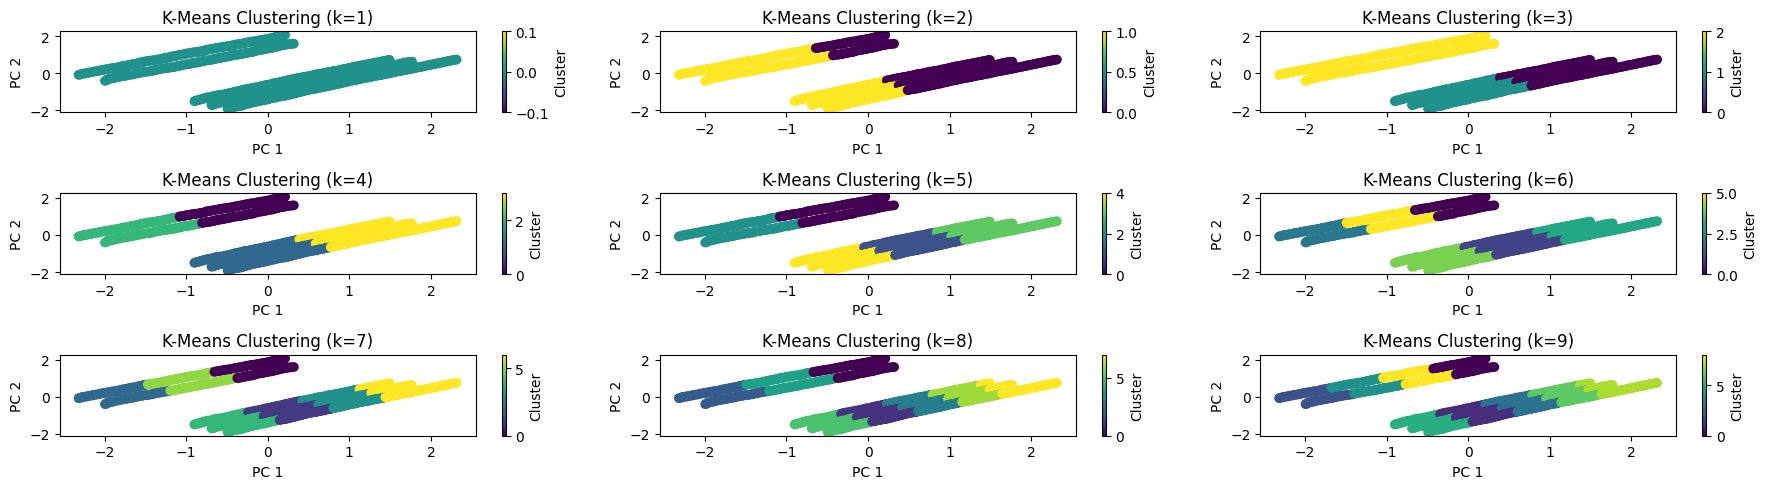

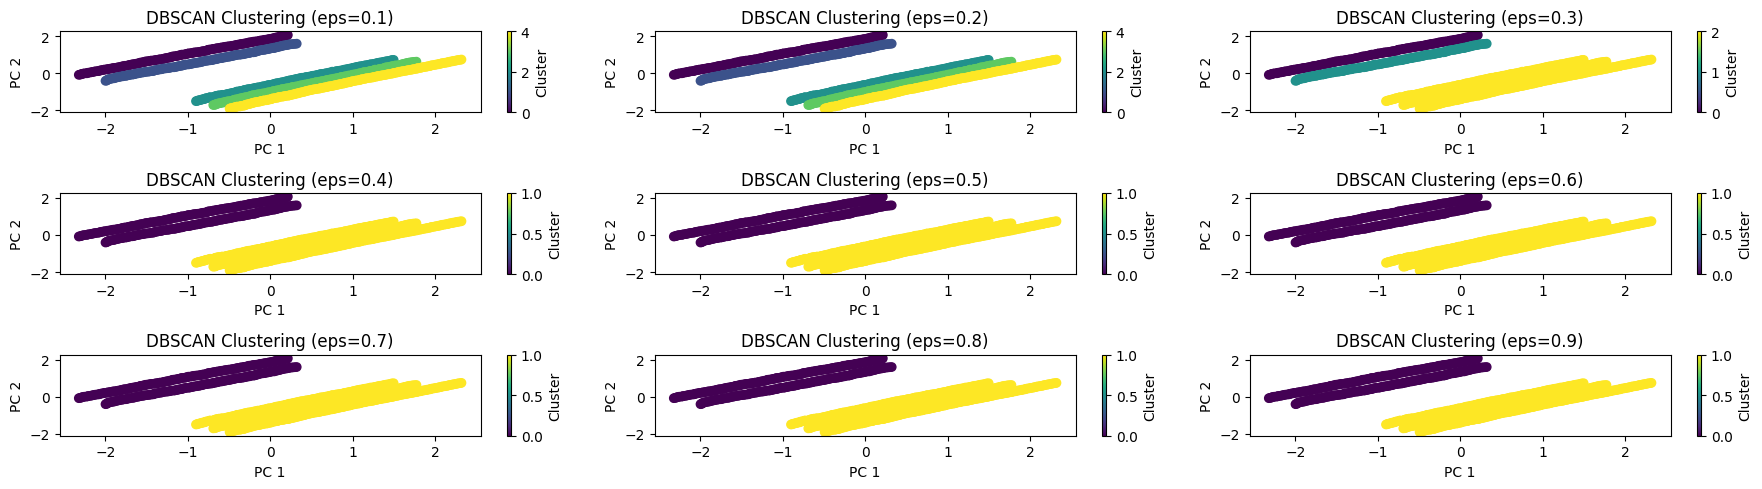

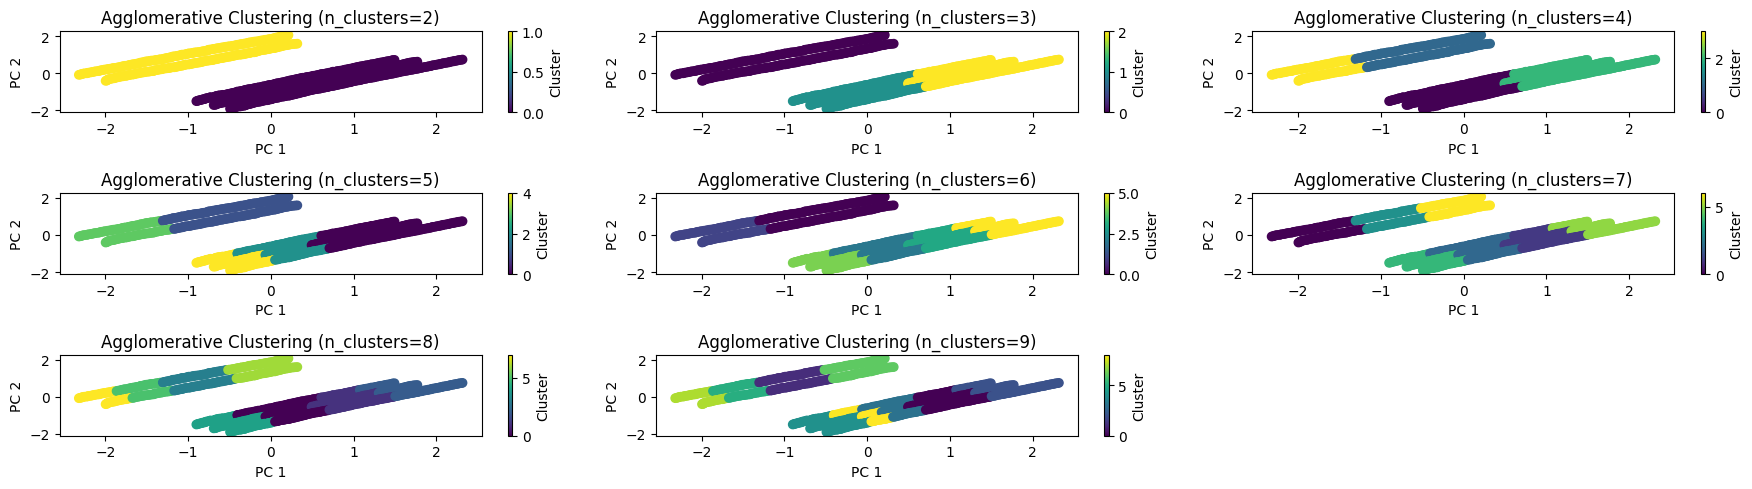

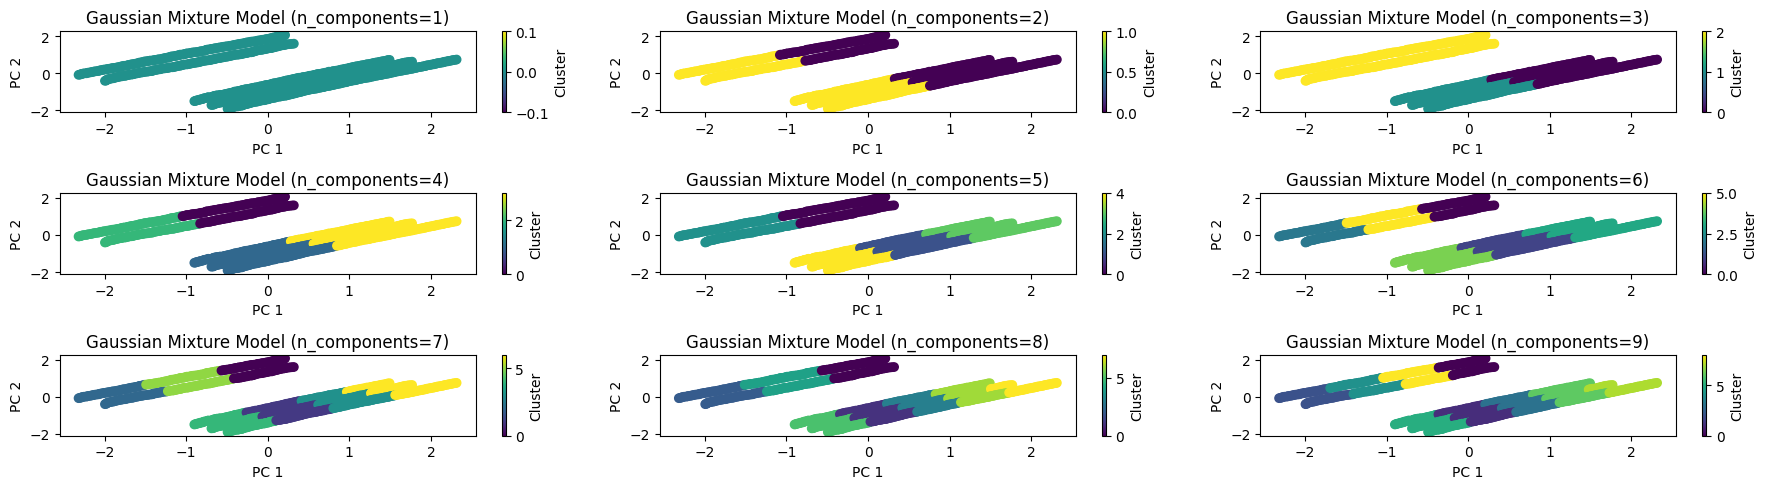

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X = data[['Gate Voltage','Gate Time', 'Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

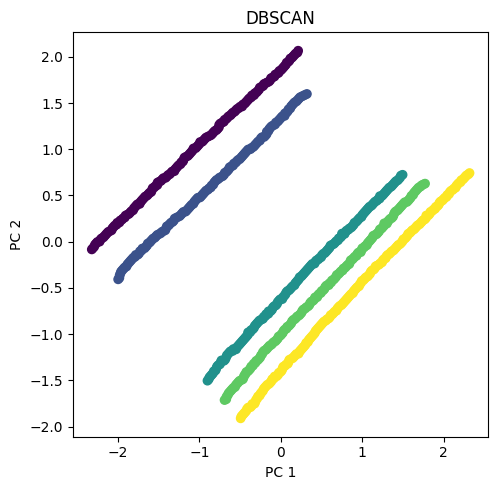

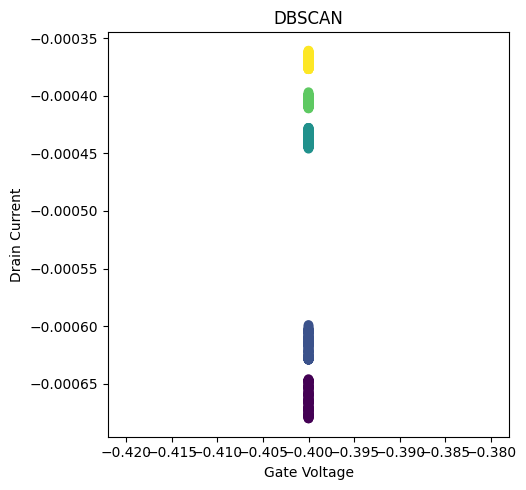

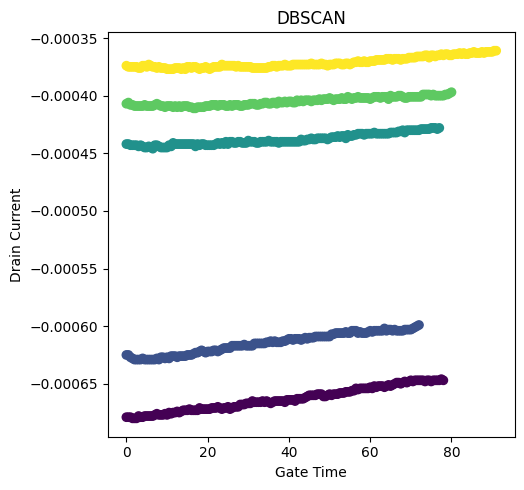

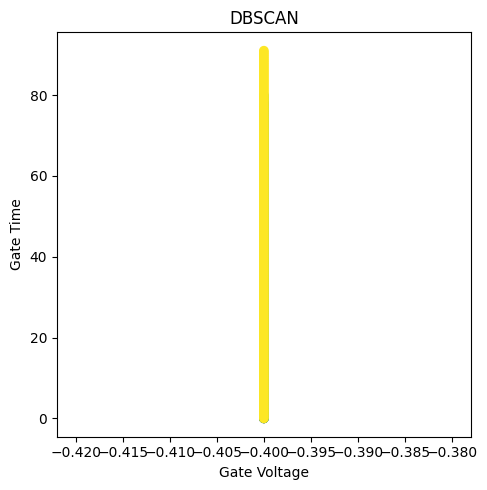

In [ ]:
#Optimal Models
# model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
# kmeans = KMeans(n_clusters=5, random_state=42)
# kmeans_labels = kmeans.fit_predict(X_pca)
# predictions_un.append(kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
predictions_un.append(dbscan_labels)

# Hierarchical Clustering
# agglo = AgglomerativeClustering(n_clusters=5)
# agglo_labels = agglo.fit_predict(X_pca)
# predictions_un.append(agglo_labels)

# Gaussian Mixture Model
# gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
# gmm_labels = gmm.fit_predict(X_pca)
# predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()

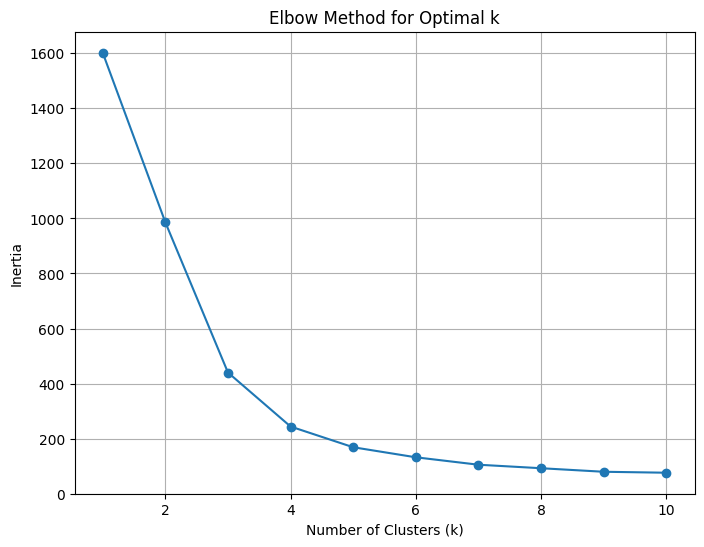

In [ ]:
# Tuning KMeans parameters (example)
inertia_values = []
for k in range(1, 11):  # Test k values from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia_values.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

#With Gate Voltage and Drain Current

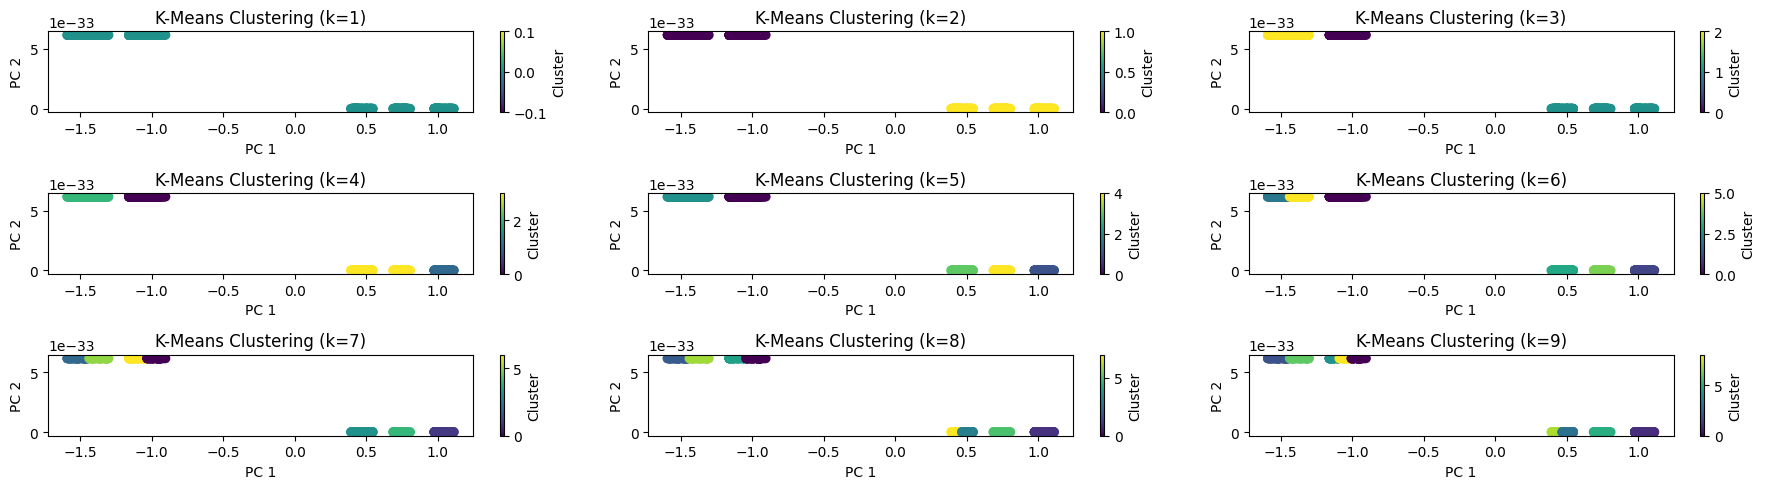

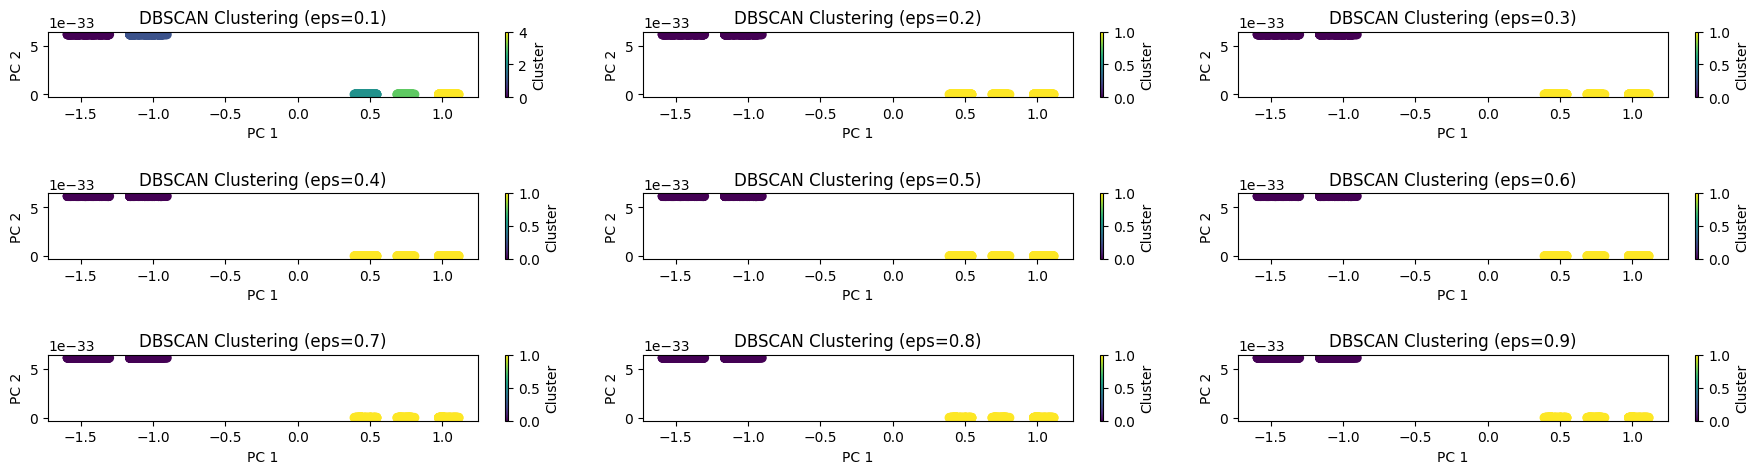

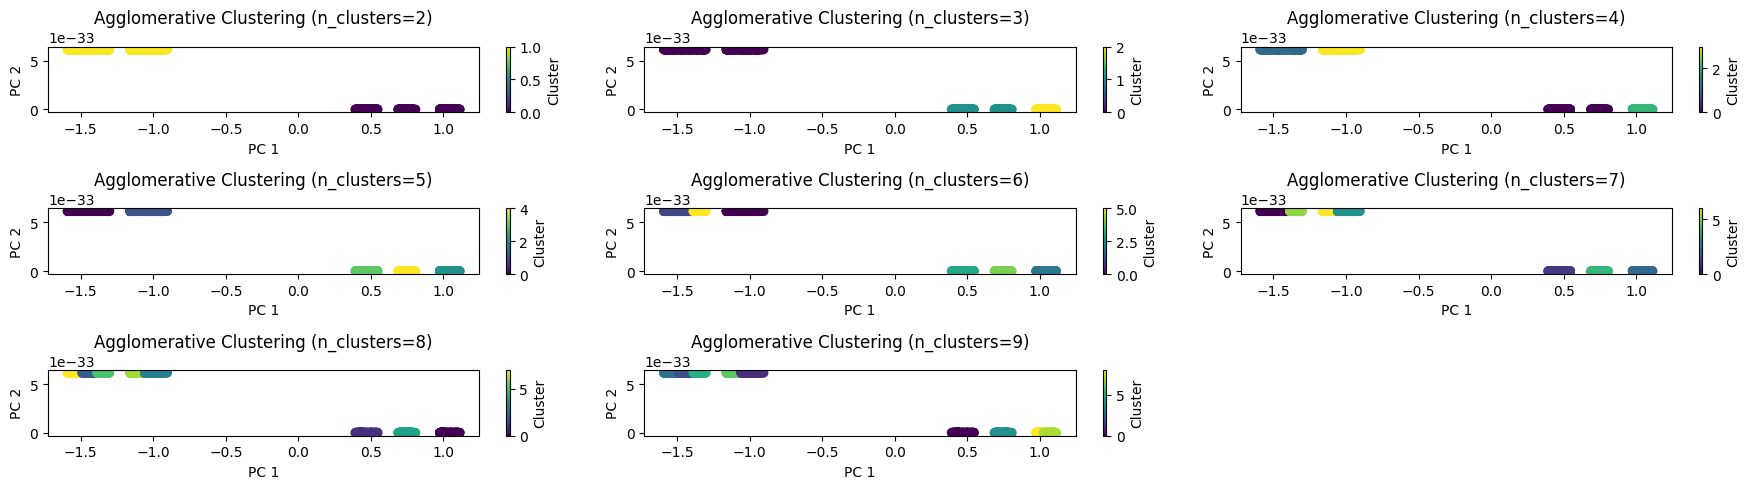

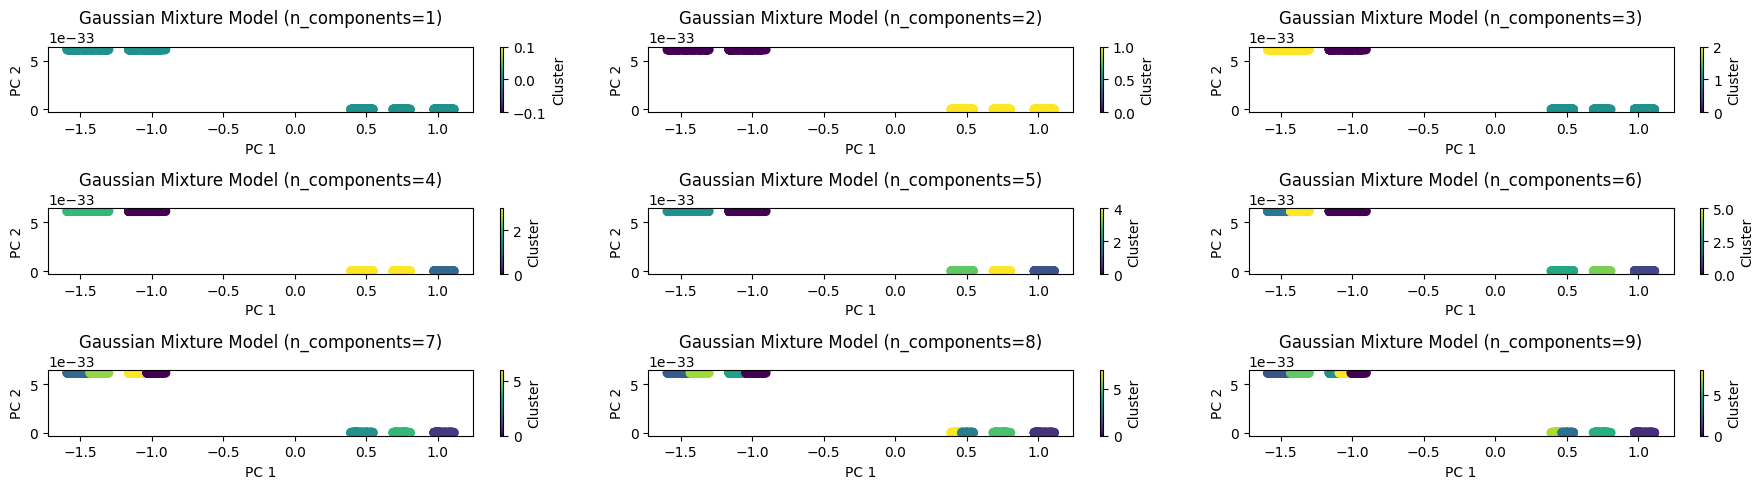

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X = data[['Gate Voltage', 'Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

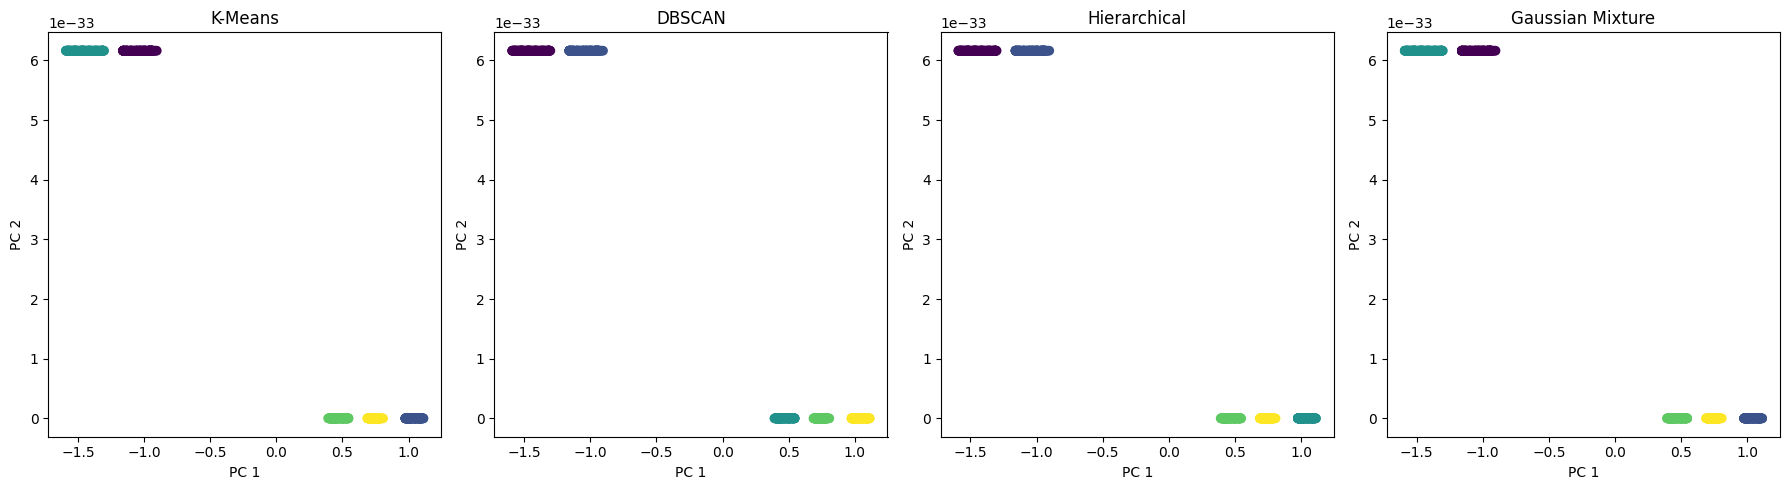

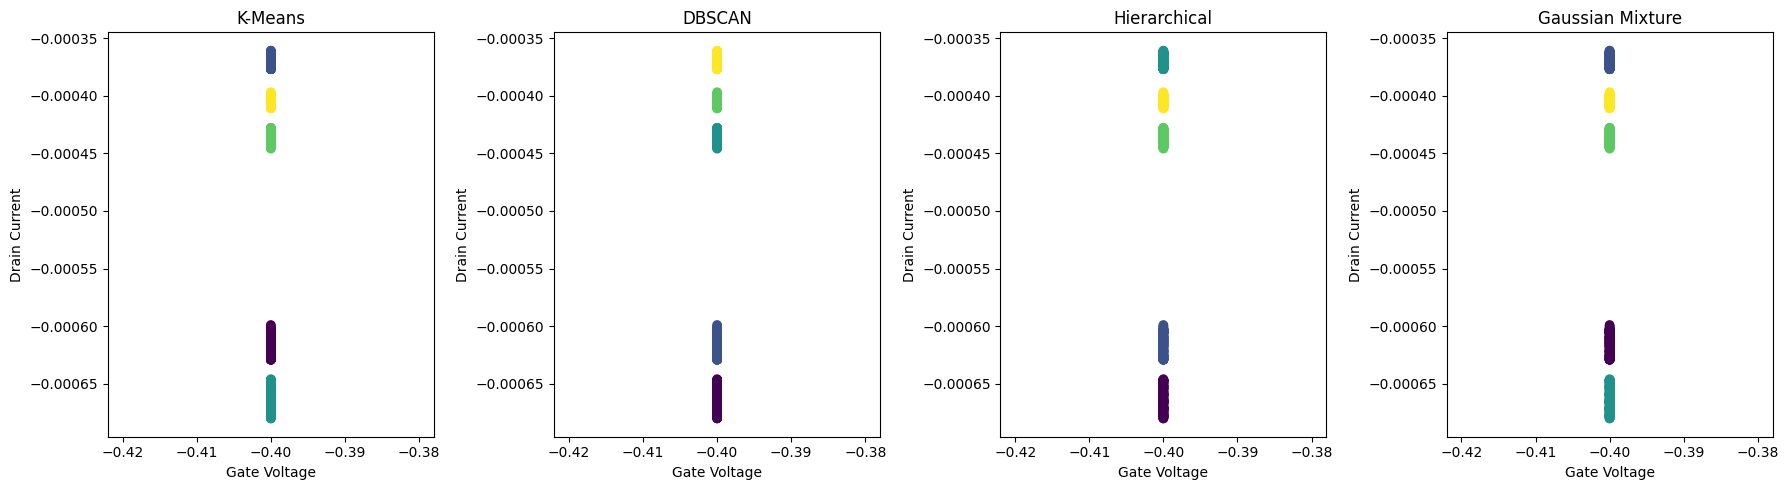

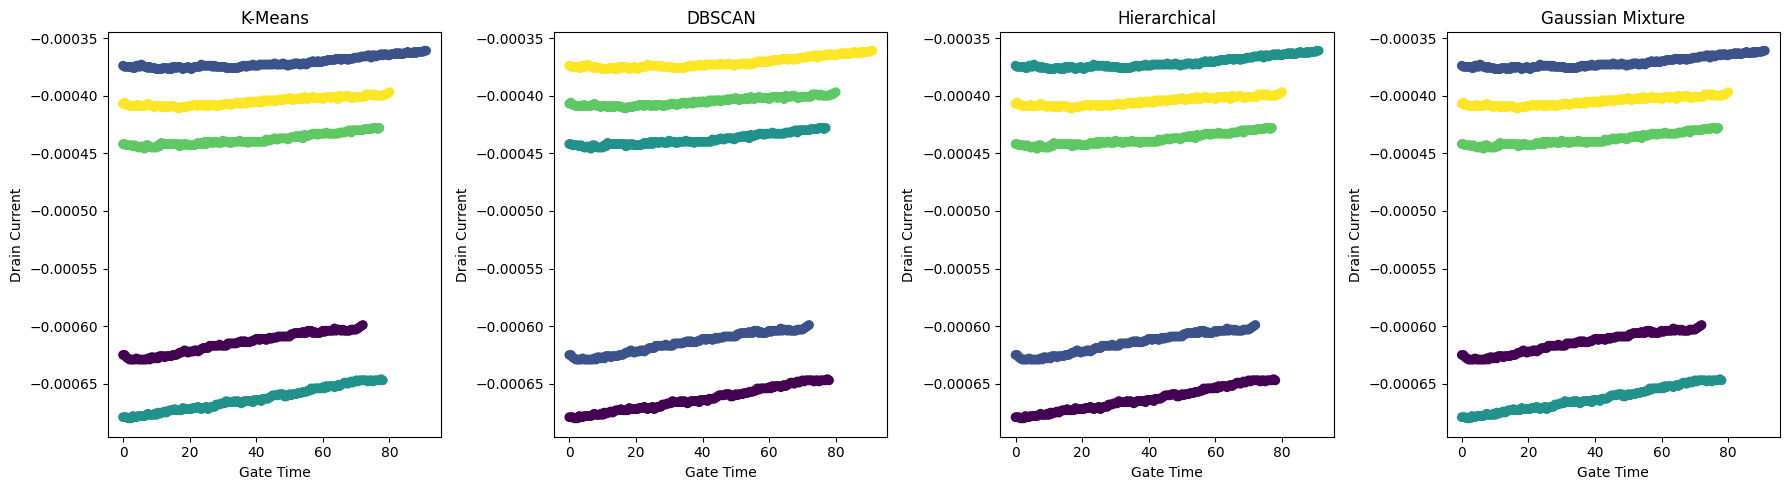

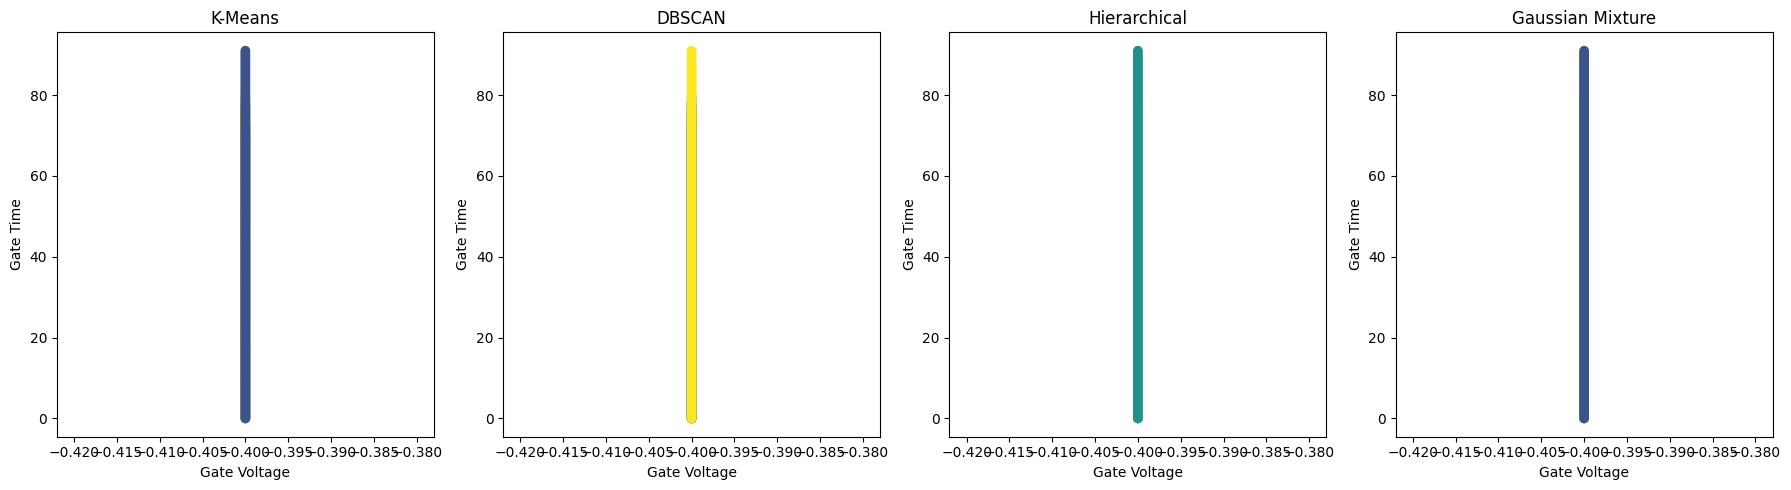

In [ ]:
#Optimal Models
model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
predictions_un.append(kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
predictions_un.append(dbscan_labels)

# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(X_pca)
predictions_un.append(agglo_labels)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
gmm_labels = gmm.fit_predict(X_pca)
predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()

#With Gate Time and Drain Current

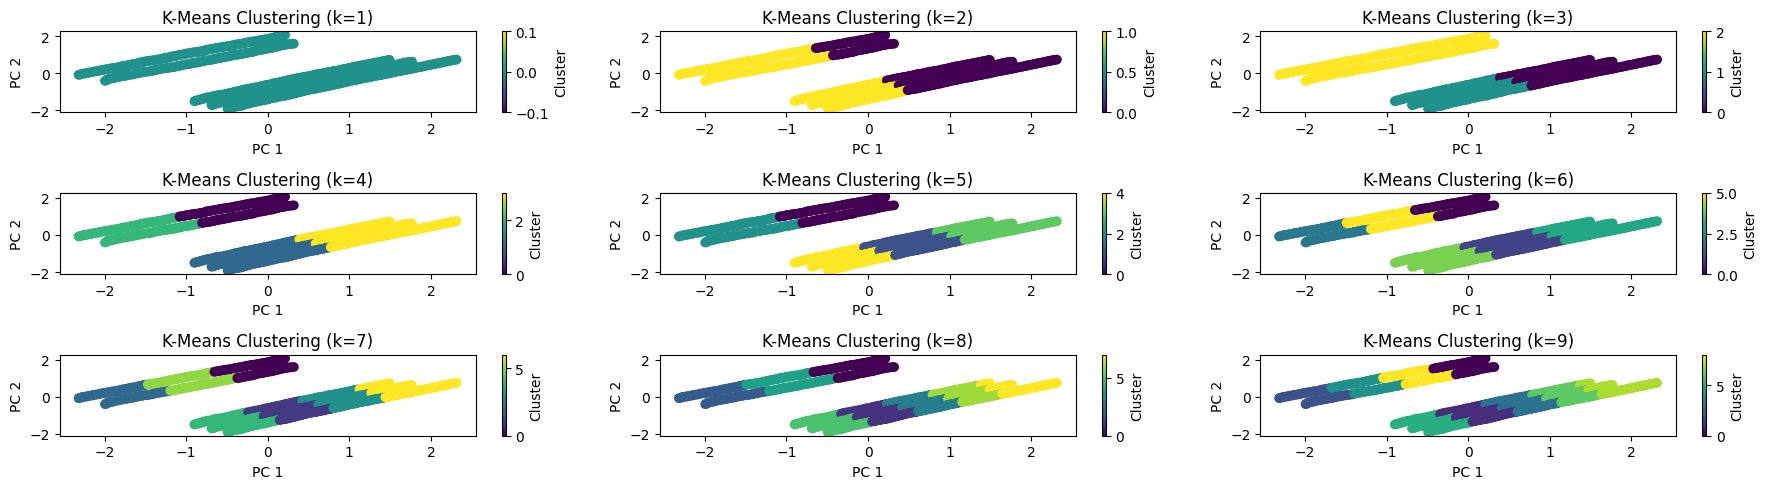

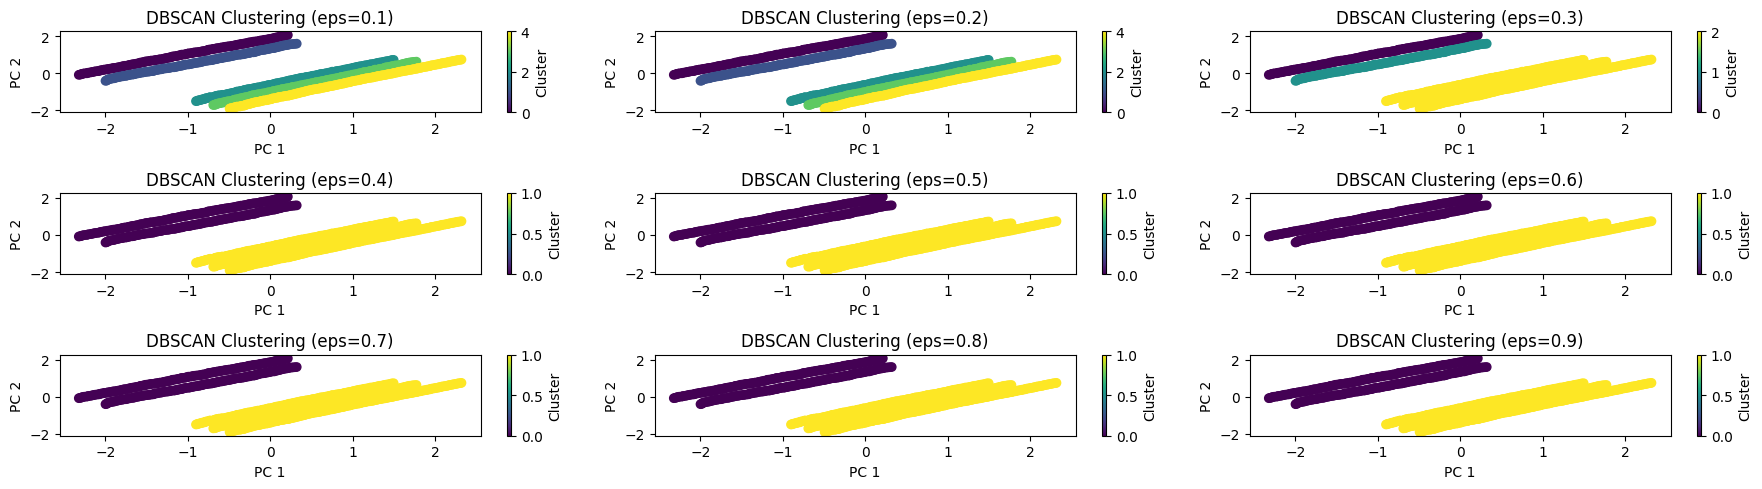

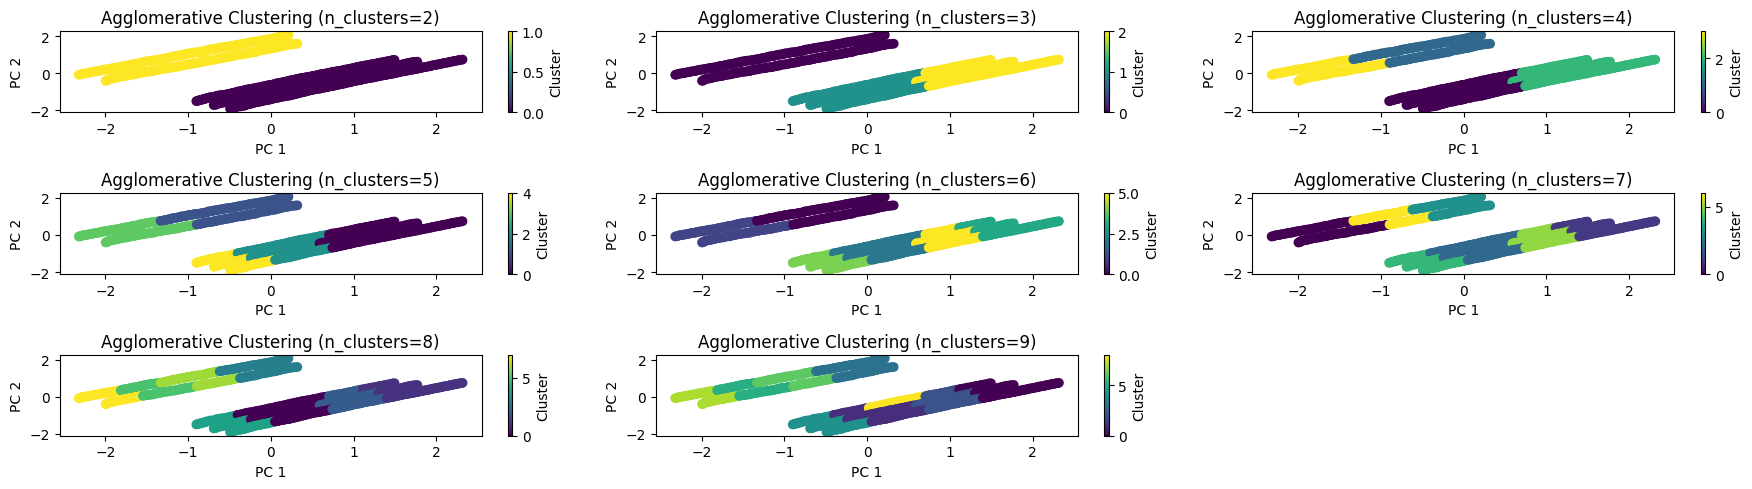

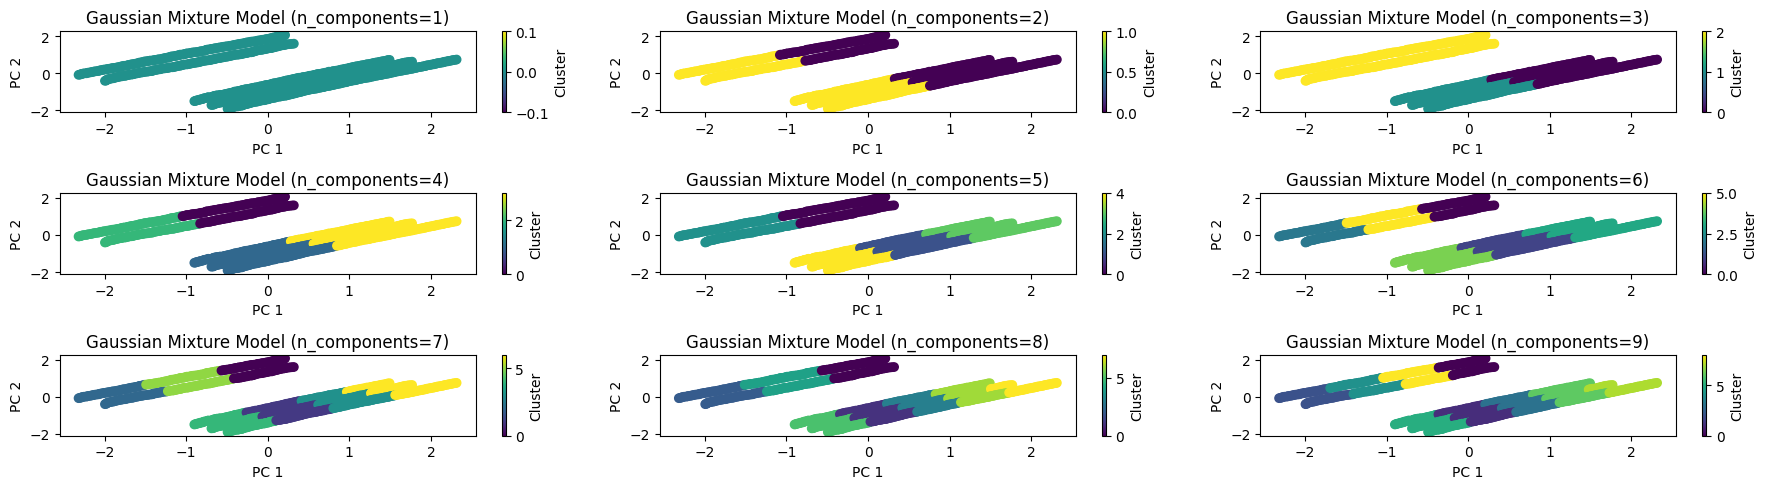

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X = data[['Gate Time', 'Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize results for optimal model after PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

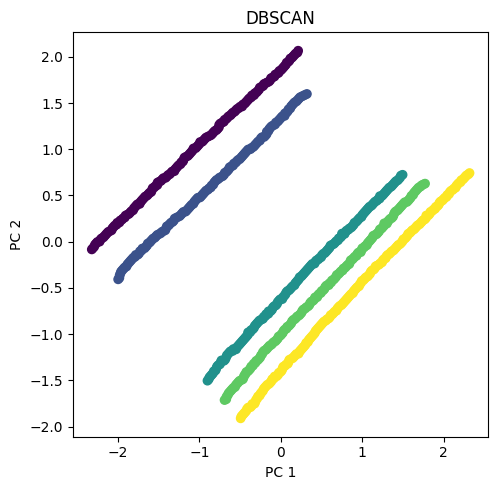

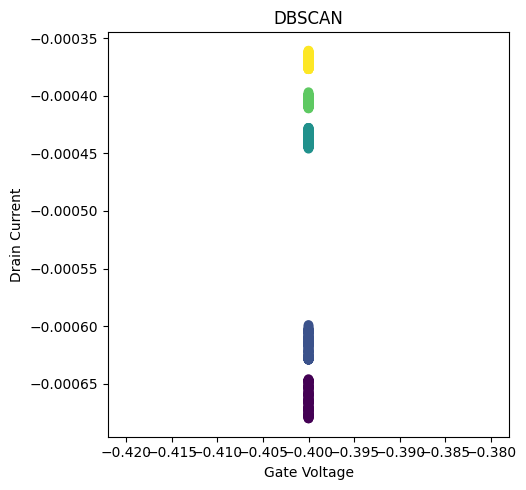

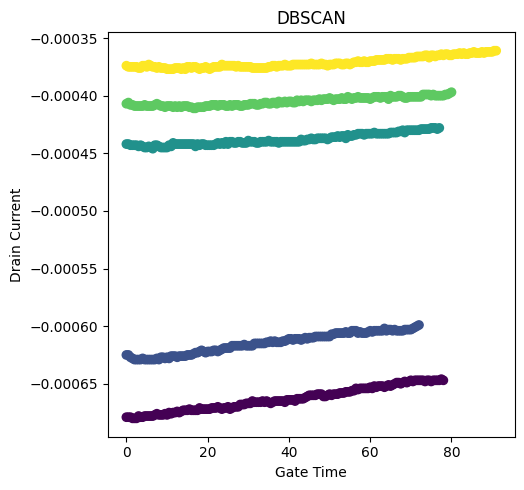

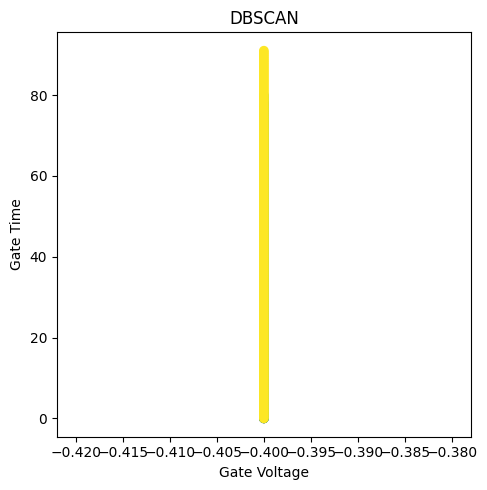

In [ ]:
#Optimal Models
# model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
# kmeans = KMeans(n_clusters=5, random_state=42)
# kmeans_labels = kmeans.fit_predict(X_pca)
# predictions_un.append(kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
predictions_un.append(dbscan_labels)

# Hierarchical Clustering
# agglo = AgglomerativeClustering(n_clusters=5)
# agglo_labels = agglo.fit_predict(X_pca)
# predictions_un.append(agglo_labels)

# Gaussian Mixture Model
# gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
# gmm_labels = gmm.fit_predict(X_pca)
# predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un[1:2]):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()

#Only Drain Current

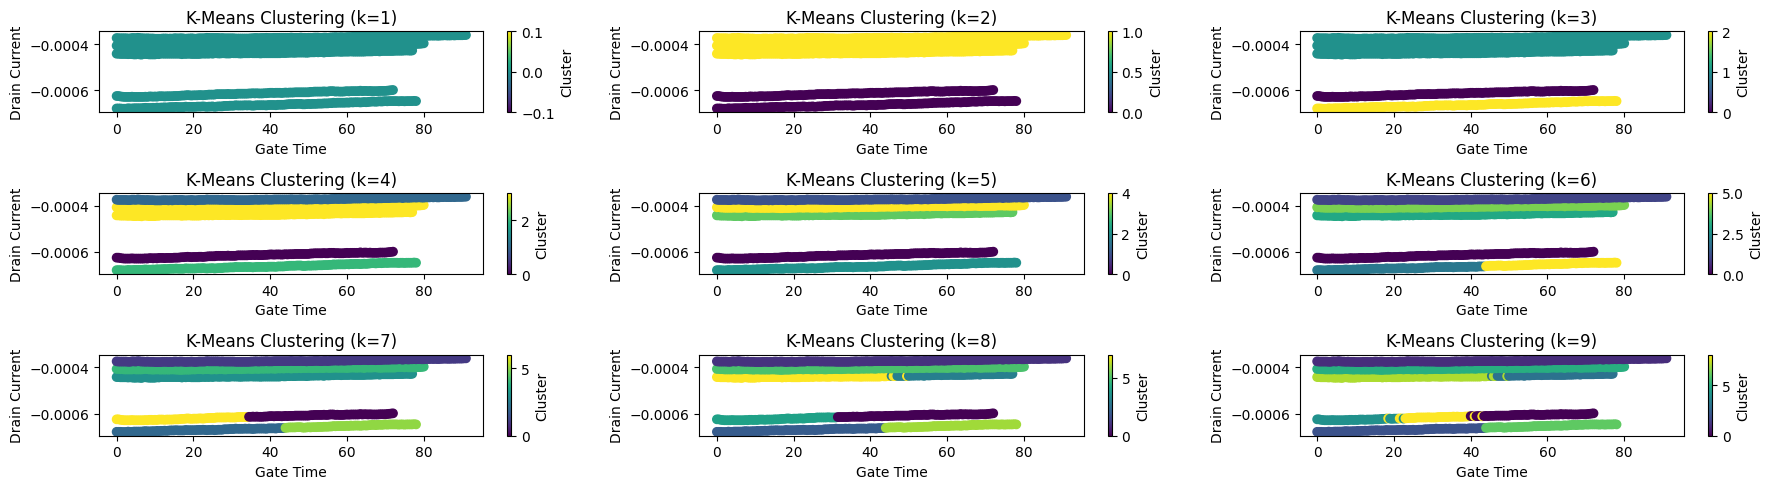

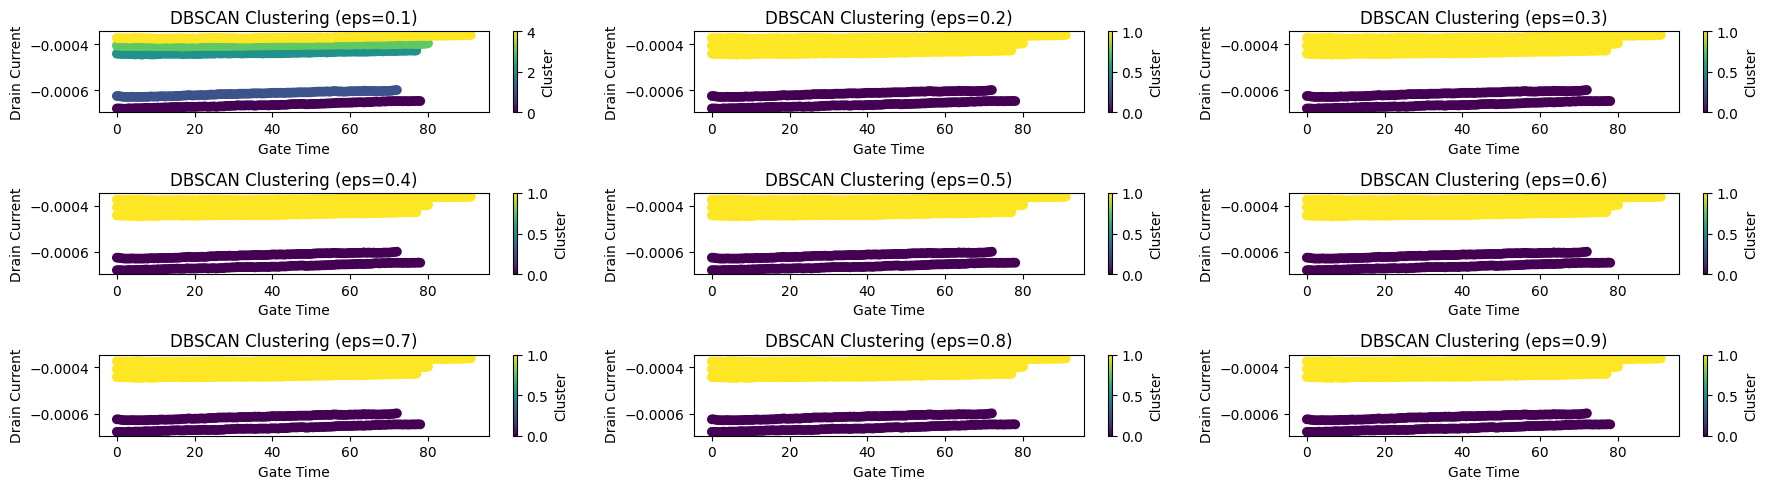

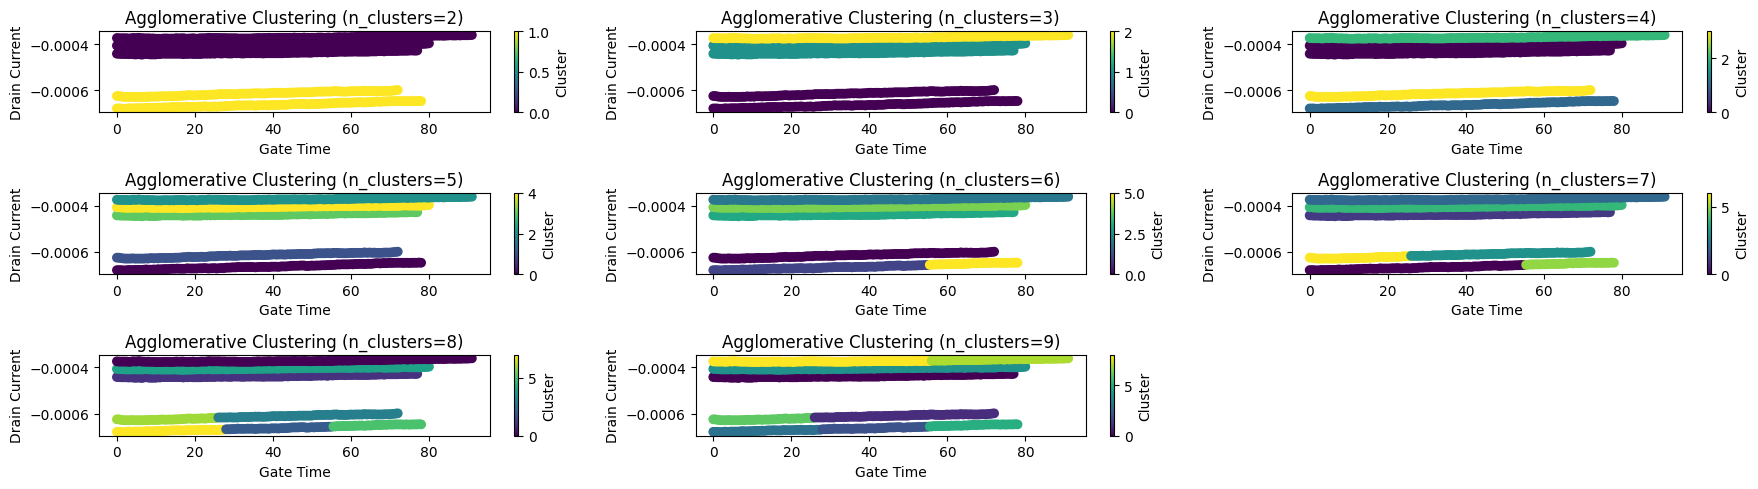

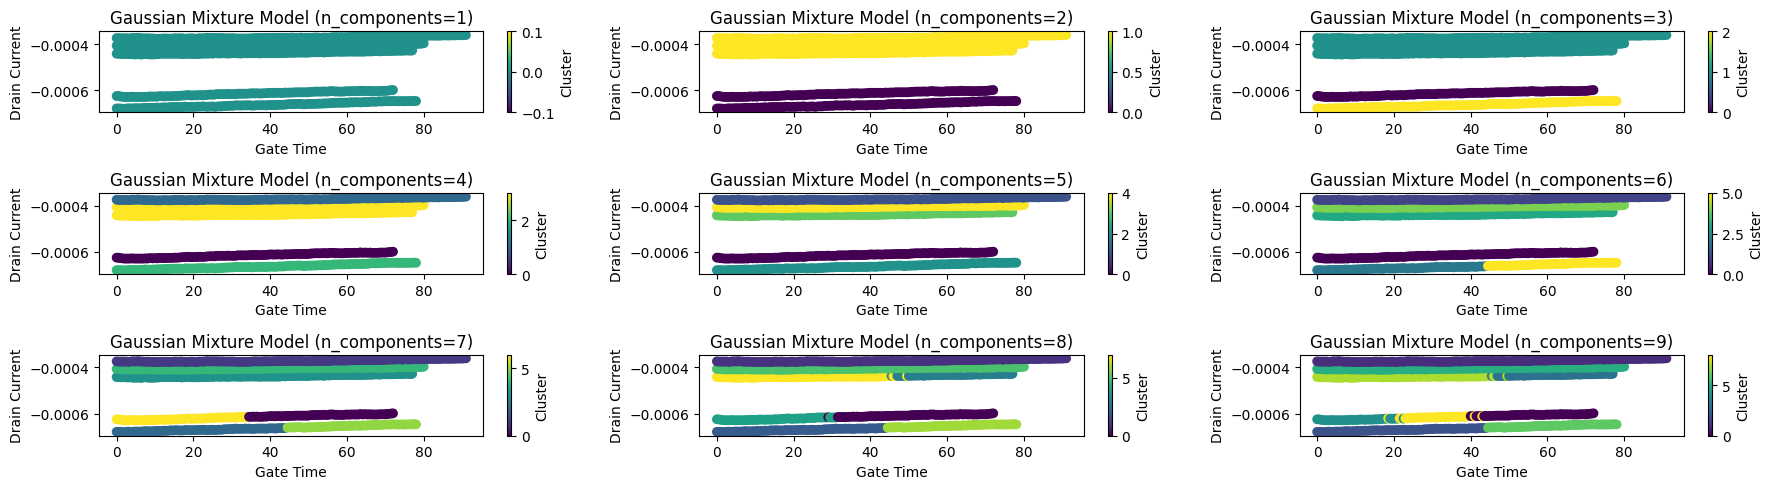

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Define features
X = data[['Drain Current']]  # Using Gate Time and Drain Current for clustering

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize results for optimal model after PCA
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']

# Plotting the results
plt.figure(figsize=(18, 5))
for i in range(1,10):
    kmeans_optimal = KMeans(n_clusters=i, random_state=42)
    kmeans_labels_optimal = kmeans_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=kmeans_labels_optimal, cmap='viridis')
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
    plt.title(f'K-Means Clustering (k={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for DBSCAN
plt.figure(figsize=(18, 5))
for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dbscan_optimal = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels_optimal = dbscan_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, int(eps*10))
    plt.scatter(data['Gate Time'], data['Drain Current'], c=dbscan_labels_optimal, cmap='viridis')
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
    plt.title(f'DBSCAN Clustering (eps={eps})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Agglomerative Clustering
plt.figure(figsize=(18, 5))
for i in range(2,10):
    agglo_optimal = AgglomerativeClustering(n_clusters=i)
    agglo_labels_optimal = agglo_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i-1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=agglo_labels_optimal, cmap='viridis')
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
    plt.title(f'Agglomerative Clustering (n_clusters={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

# Plotting the results for Gaussian Mixture Model
plt.figure(figsize=(18, 5))
for i in range(1,10):
    gmm_optimal = GaussianMixture(n_components=i, random_state=42)
    gmm_labels_optimal = gmm_optimal.fit_predict(X_pca)
    plt.subplot(3, 3, i)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=gmm_labels_optimal, cmap='viridis')
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
    plt.title(f'Gaussian Mixture Model (n_components={i})')
    plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

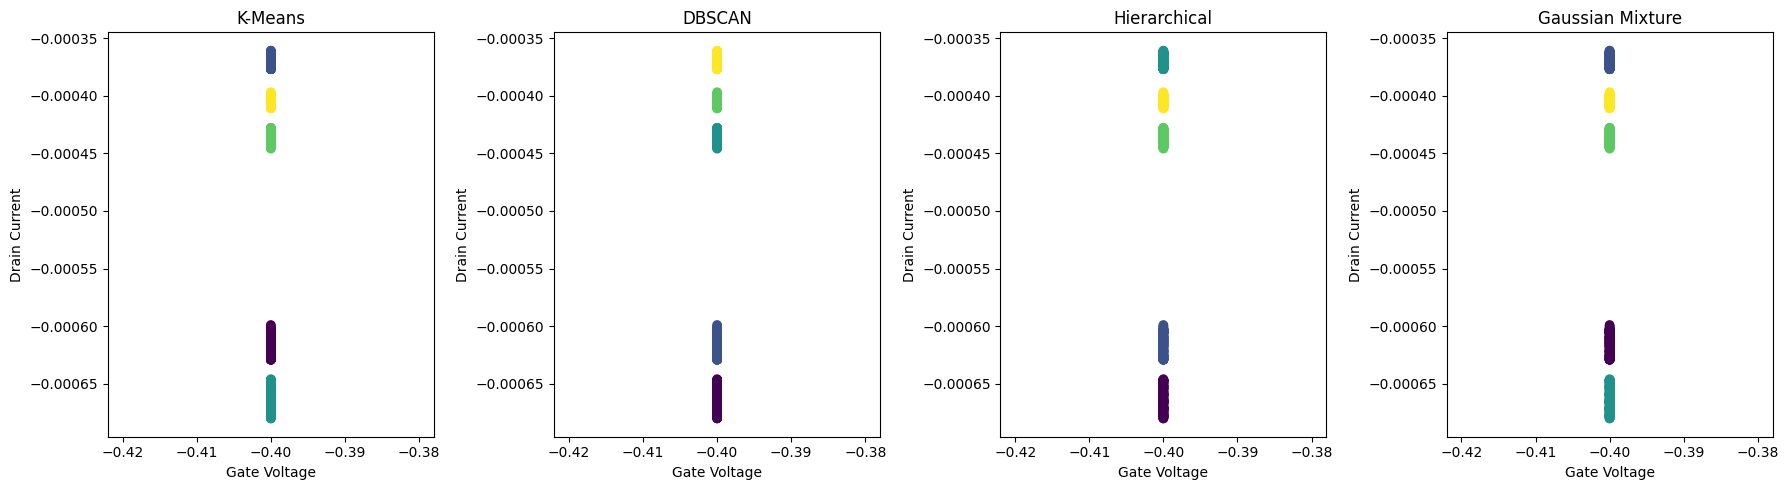

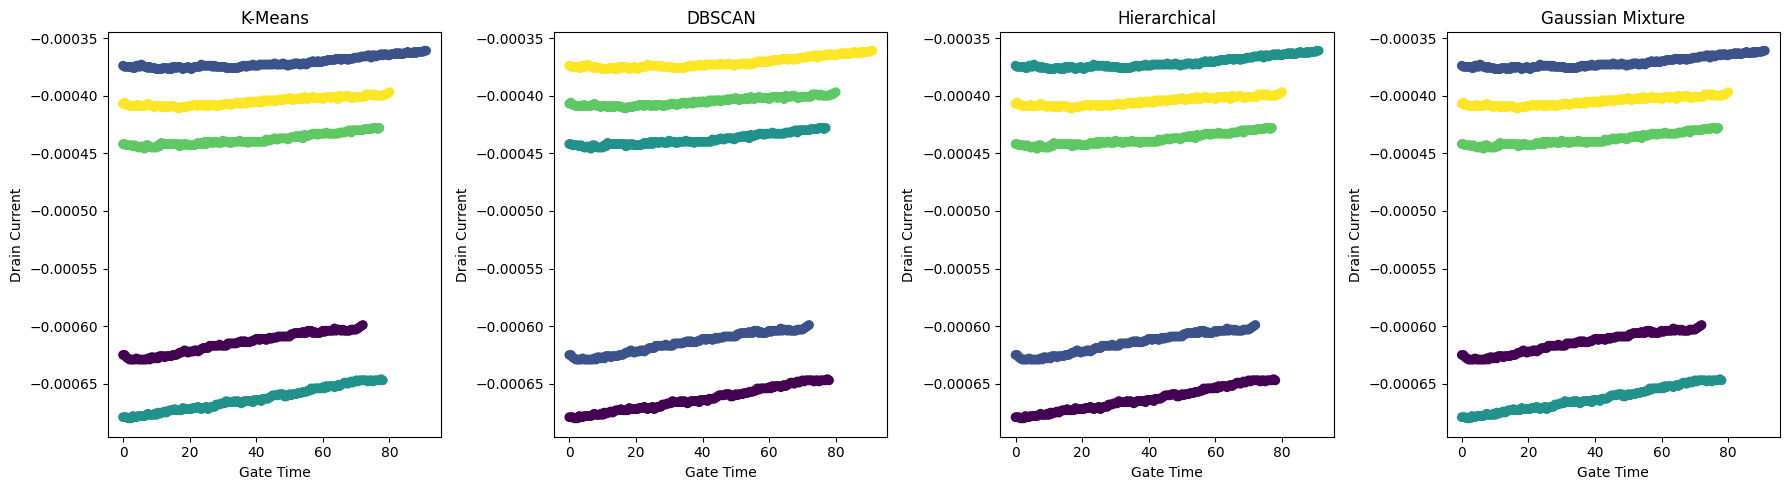

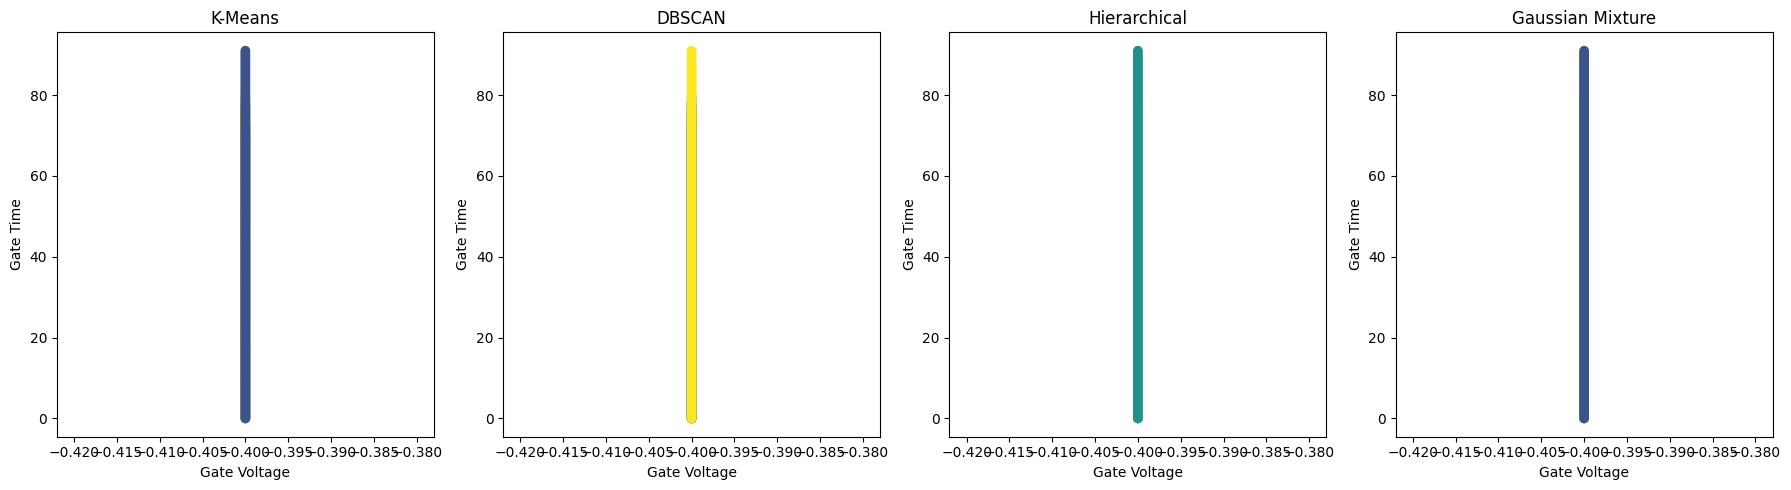

In [ ]:
#Optimal Models
model_names_un = ['K-Means', 'DBSCAN', 'Hierarchical', 'Gaussian Mixture']
predictions_un = []

# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
predictions_un.append(kmeans_labels)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)
predictions_un.append(dbscan_labels)

# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(X_pca)
predictions_un.append(agglo_labels)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42) # Adjust n_components as needed
gmm_labels = gmm.fit_predict(X_pca)
predictions_un.append(gmm_labels)

# Apply PCA for visualization
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# Plotting the results
# plt.figure(figsize=(18, 5))
# for i, name in enumerate(model_names_un):
#     plt.subplot(1, 4, i + 1)
#     plt.scatter(X_pca[:, 0], X_pca[:, 1], c=predictions_un[i], cmap='viridis', label=name)
#     plt.title(name)
#     plt.xlabel('PC 1')
#     plt.ylabel('PC 2')
# plt.tight_layout()
# plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Time'], data['Drain Current'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Time')
    plt.ylabel('Drain Current')
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(18, 5))
for i, name in enumerate(model_names_un):
    plt.subplot(1, 4, i + 1)
    plt.scatter(data['Gate Voltage'], data['Gate Time'], c=predictions_un[i], cmap='viridis', label=name)
    plt.title(name)
    plt.xlabel('Gate Voltage')
    plt.ylabel('Gate Time')
plt.tight_layout()
plt.show()